In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import missingno as msno
except ImportError:
    msno = None


In [2]:
energy = pd.read_csv("energy_dataset.csv")
weather = pd.read_csv("weather_features.csv")

print("Energy dataset:", energy.shape)
print("Weather dataset:", weather.shape)

Energy dataset: (35064, 29)
Weather dataset: (178396, 17)


In [3]:
print("===== ENERGY DATASET =====")
print(energy.head())

===== ENERGY DATASET =====
                        time  generation biomass  \
0  2015-01-01 00:00:00+01:00               447.0   
1  2015-01-01 01:00:00+01:00               449.0   
2  2015-01-01 02:00:00+01:00               448.0   
3  2015-01-01 03:00:00+01:00               438.0   
4  2015-01-01 04:00:00+01:00               428.0   

   generation fossil brown coal/lignite  generation fossil coal-derived gas  \
0                                 329.0                                 0.0   
1                                 328.0                                 0.0   
2                                 323.0                                 0.0   
3                                 254.0                                 0.0   
4                                 187.0                                 0.0   

   generation fossil gas  generation fossil hard coal  generation fossil oil  \
0                 4844.0                       4821.0                  162.0   
1                 5196.0 

In [4]:
print("===== WEATHER DATASET =====")
print(weather.head())

===== WEATHER DATASET =====
                      dt_iso city_name     temp  temp_min  temp_max  pressure  \
0  2015-01-01 00:00:00+01:00  Valencia  270.475   270.475   270.475      1001   
1  2015-01-01 01:00:00+01:00  Valencia  270.475   270.475   270.475      1001   
2  2015-01-01 02:00:00+01:00  Valencia  269.686   269.686   269.686      1002   
3  2015-01-01 03:00:00+01:00  Valencia  269.686   269.686   269.686      1002   
4  2015-01-01 04:00:00+01:00  Valencia  269.686   269.686   269.686      1002   

   humidity  wind_speed  wind_deg  rain_1h  rain_3h  snow_3h  clouds_all  \
0        77           1        62      0.0      0.0      0.0           0   
1        77           1        62      0.0      0.0      0.0           0   
2        78           0        23      0.0      0.0      0.0           0   
3        78           0        23      0.0      0.0      0.0           0   
4        78           0        23      0.0      0.0      0.0           0   

   weather_id weather_main w

In [5]:
print("===== ENERGY INFO =====")
energy.info()

===== ENERGY INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  str    
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null

In [6]:
print("===== WEATHER INFO =====")
weather.info()

===== WEATHER INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  str    
 1   city_name            178396 non-null  str    
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  str    
 15  wea

1. HANDLING MISSING VALUE 

In [7]:
print("===== ENERGY MISSING VALUES =====")
print(energy.isnull().sum())

print("\n===== WEATHER MISSING VALUES =====")
print(weather.isnull().sum())

===== ENERGY MISSING VALUES =====
time                                               0
generation biomass                                19
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation fossil gas                             18
generation fossil hard coal                       18
generation fossil oil                             19
generation fossil oil shale                       18
generation fossil peat                            18
generation geothermal                             18
generation hydro pumped storage aggregated     35064
generation hydro pumped storage consumption       19
generation hydro run-of-river and poundage        19
generation hydro water reservoir                  18
generation marine                                 19
generation nuclear                                17
generation other                                  18
generation other renewable                        18
generation s

In [8]:
print("===== ENERGY MISSING PERCENTAGE =====")
print((energy.isnull().sum() / len(energy) * 100).sort_values(ascending=False))

print("\n===== WEATHER MISSING PERCENTAGE =====")
print((weather.isnull().sum() / len(weather) * 100).sort_values(ascending=False))

===== ENERGY MISSING PERCENTAGE =====
generation hydro pumped storage aggregated     100.000000
forecast wind offshore eday ahead              100.000000
total load actual                                0.102669
generation hydro run-of-river and poundage       0.054187
generation hydro pumped storage consumption      0.054187
generation waste                                 0.054187
generation marine                                0.054187
generation fossil oil                            0.054187
generation biomass                               0.054187
generation fossil peat                           0.051335
generation fossil gas                            0.051335
generation fossil brown coal/lignite             0.051335
generation fossil coal-derived gas               0.051335
generation wind onshore                          0.051335
generation geothermal                            0.051335
generation fossil oil shale                      0.051335
generation fossil hard coal       

1.1 Phân tích các vị trí missing

In [9]:
missing_percentage = (energy.isnull().sum() / len(energy)) * 100

print("===== COLUMNS WITH MISSING VALUES =====")

for column, percentage in missing_percentage.items():
    if percentage > 0:
        print(f"{column}: {percentage:.3f}%")

===== COLUMNS WITH MISSING VALUES =====
generation biomass: 0.054%
generation fossil brown coal/lignite: 0.051%
generation fossil coal-derived gas: 0.051%
generation fossil gas: 0.051%
generation fossil hard coal: 0.051%
generation fossil oil: 0.054%
generation fossil oil shale: 0.051%
generation fossil peat: 0.051%
generation geothermal: 0.051%
generation hydro pumped storage aggregated: 100.000%
generation hydro pumped storage consumption: 0.054%
generation hydro run-of-river and poundage: 0.054%
generation hydro water reservoir: 0.051%
generation marine: 0.054%
generation nuclear: 0.048%
generation other: 0.051%
generation other renewable: 0.051%
generation solar: 0.051%
generation waste: 0.054%
generation wind offshore: 0.051%
generation wind onshore: 0.051%
forecast wind offshore eday ahead: 100.000%
total load actual: 0.103%


In [10]:
# Loại 2 cột bị missing 100%
cols_100_missing = [
    'generation hydro pumped storage aggregated',
    'forecast wind offshore eday ahead'
]

energy_check = energy.drop(columns=cols_100_missing)

# Các dòng có ít nhất một giá trị missing
missing_rows = energy_check[
    energy_check.isnull().any(axis=1)
]

print("Số dòng có missing:", len(missing_rows))

Số dòng có missing: 47


In [11]:
print("Các thời điểm có missing:")

print(
    missing_rows[['time']]
    .to_string(index=False)
)

Các thời điểm có missing:
                     time
2015-01-05 03:00:00+01:00
2015-01-05 12:00:00+01:00
2015-01-05 13:00:00+01:00
2015-01-05 14:00:00+01:00
2015-01-05 15:00:00+01:00
2015-01-05 16:00:00+01:00
2015-01-05 17:00:00+01:00
2015-01-19 19:00:00+01:00
2015-01-19 20:00:00+01:00
2015-01-27 19:00:00+01:00
2015-01-28 13:00:00+01:00
2015-02-01 07:00:00+01:00
2015-02-01 08:00:00+01:00
2015-02-01 09:00:00+01:00
2015-02-01 12:00:00+01:00
2015-02-01 13:00:00+01:00
2015-02-01 14:00:00+01:00
2015-02-01 15:00:00+01:00
2015-02-01 16:00:00+01:00
2015-02-01 17:00:00+01:00
2015-02-01 18:00:00+01:00
2015-02-01 19:00:00+01:00
2015-04-05 03:00:00+02:00
2015-04-16 09:00:00+02:00
2015-04-20 08:00:00+02:00
2015-04-23 21:00:00+02:00
2015-05-02 10:00:00+02:00
2015-05-29 03:00:00+02:00
2015-06-15 09:00:00+02:00
2015-10-02 08:00:00+02:00
2015-10-02 11:00:00+02:00
2015-12-02 09:00:00+01:00
2016-04-13 05:00:00+02:00
2016-04-25 05:00:00+02:00
2016-04-25 07:00:00+02:00
2016-05-10 23:00:00+02:00
2016-06-12 0

In [12]:
missing_pattern = energy_check.isnull().sum(axis=1)

pattern = pd.DataFrame({
    'time': energy_check['time'],
    'missing_count': missing_pattern
})

pattern = pattern[pattern['missing_count'] > 0]

print(pattern.to_string(index=False))

                     time  missing_count
2015-01-05 03:00:00+01:00             20
2015-01-05 12:00:00+01:00             21
2015-01-05 13:00:00+01:00             21
2015-01-05 14:00:00+01:00             21
2015-01-05 15:00:00+01:00             21
2015-01-05 16:00:00+01:00             21
2015-01-05 17:00:00+01:00             21
2015-01-19 19:00:00+01:00             20
2015-01-19 20:00:00+01:00             20
2015-01-27 19:00:00+01:00             20
2015-01-28 13:00:00+01:00             21
2015-02-01 07:00:00+01:00              1
2015-02-01 08:00:00+01:00              1
2015-02-01 09:00:00+01:00              1
2015-02-01 12:00:00+01:00              1
2015-02-01 13:00:00+01:00              1
2015-02-01 14:00:00+01:00              1
2015-02-01 15:00:00+01:00              1
2015-02-01 16:00:00+01:00              1
2015-02-01 17:00:00+01:00              1
2015-02-01 18:00:00+01:00              1
2015-02-01 19:00:00+01:00              1
2015-04-05 03:00:00+02:00              1
2015-04-16 09:00

-> Phân tích mẫu giá trị thiếu: Các giá trị thiếu không hoàn toàn ngẫu nhiên. Một số giá trị thiếu xuất hiện riêng lẻ trong một cột, trong khi những giá trị khác xuất hiện đồng thời trên nhiều cột. Ngoài ra còn có một khoảng thời gian thiếu dữ liệu liên tục từ 12:00 đến 17:00 ngày 05/01/2015, trong đó có 21 cột chứa giá trị thiếu. Do đó, các giá trị thiếu thể hiện cả mẫu riêng lẻ và mẫu theo nhóm.

<Figure size 1500x600 with 0 Axes>

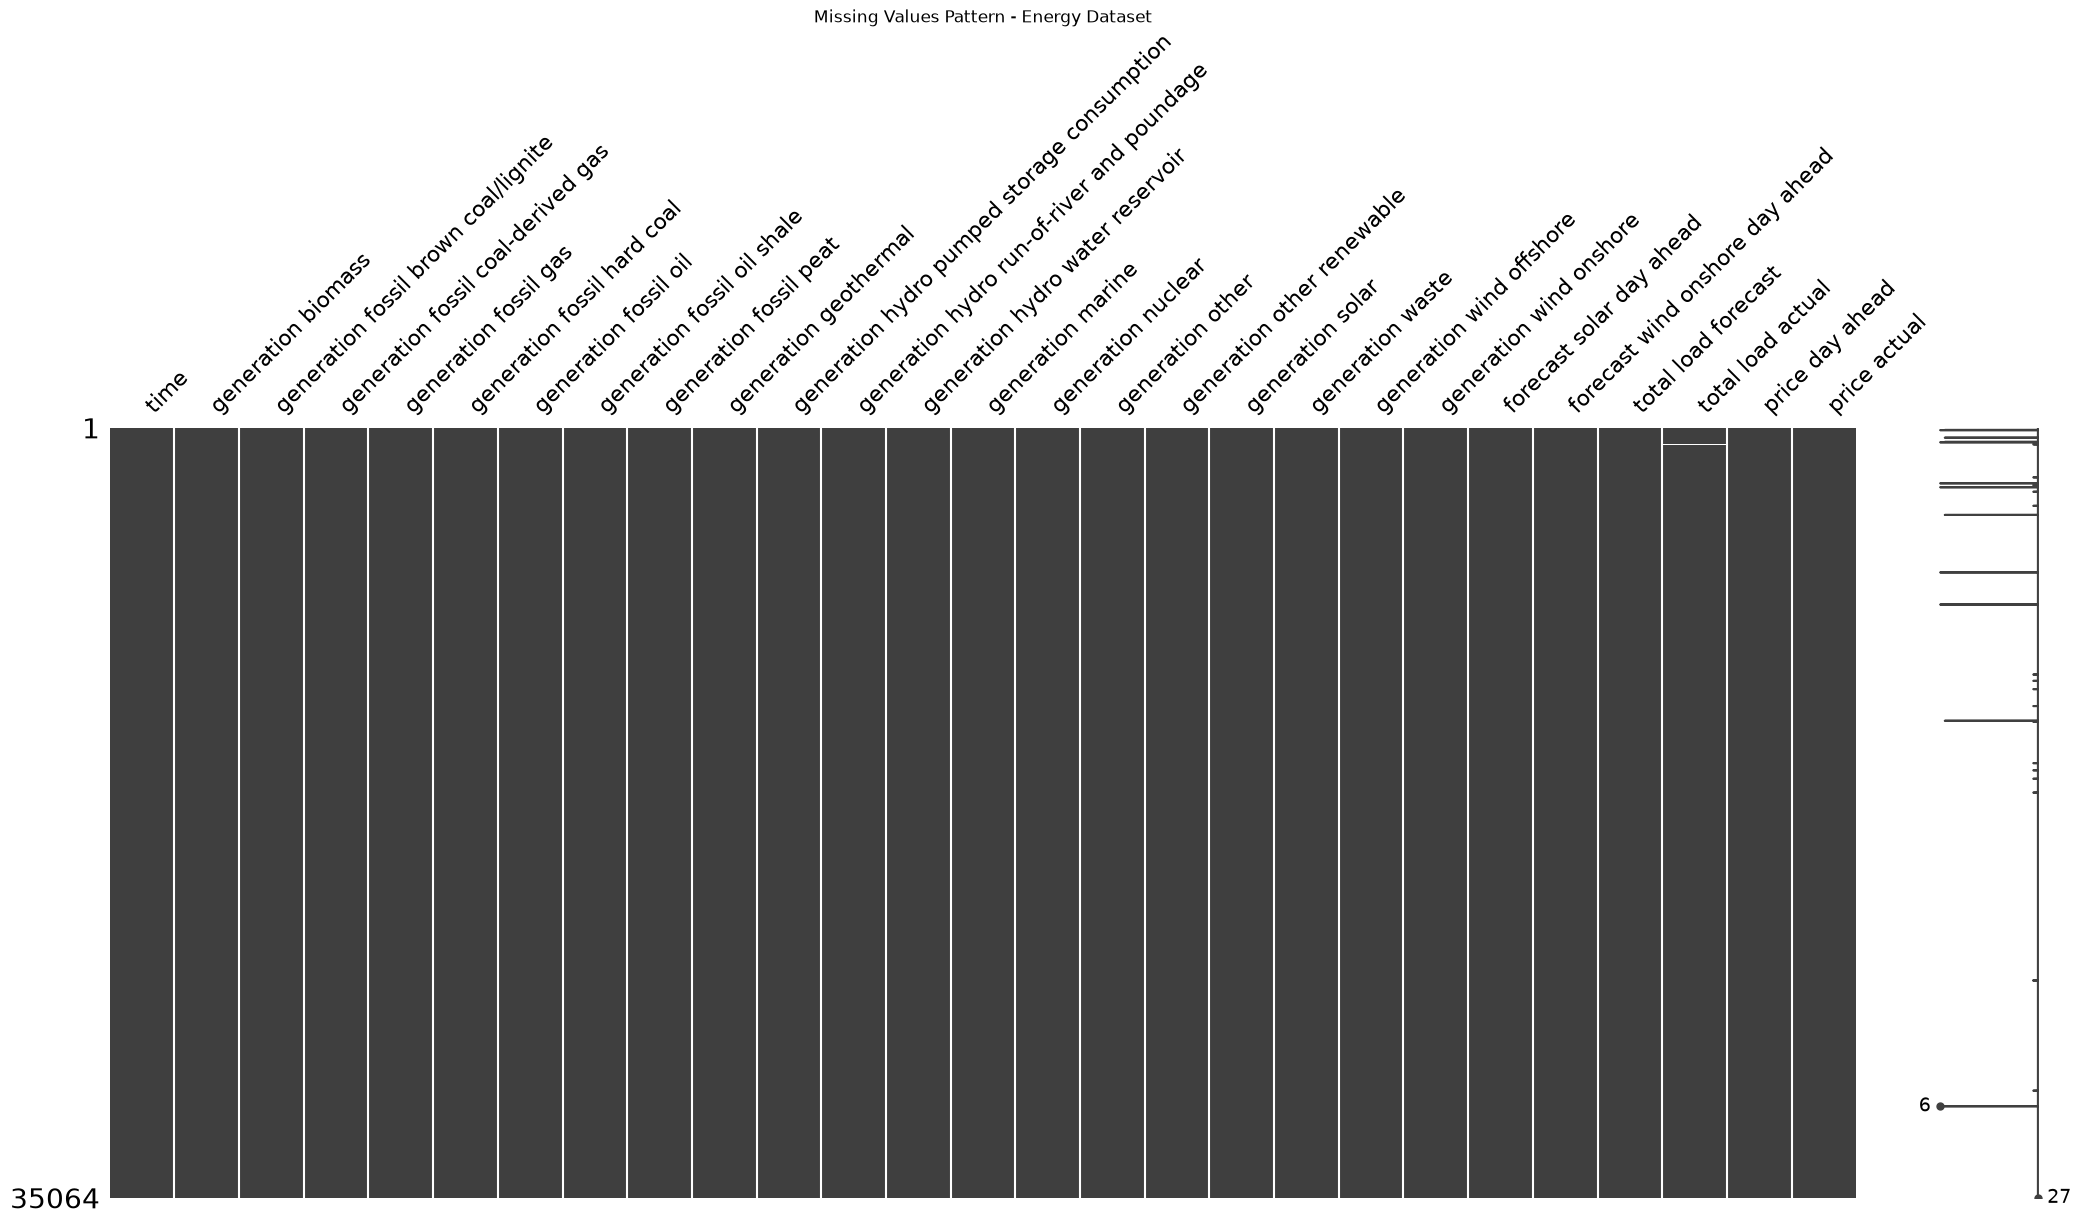

In [13]:
# Visualization of missing values pattern
plt.figure(figsize=(15, 6))

if msno is not None:
    msno.matrix(energy_check)
else:
    plt.imshow(energy_check.isnull(), aspect='auto', interpolation='nearest')
    plt.xlabel('Columns')
    plt.ylabel('Rows')

plt.title("Missing Values Pattern - Energy Dataset")
plt.show()


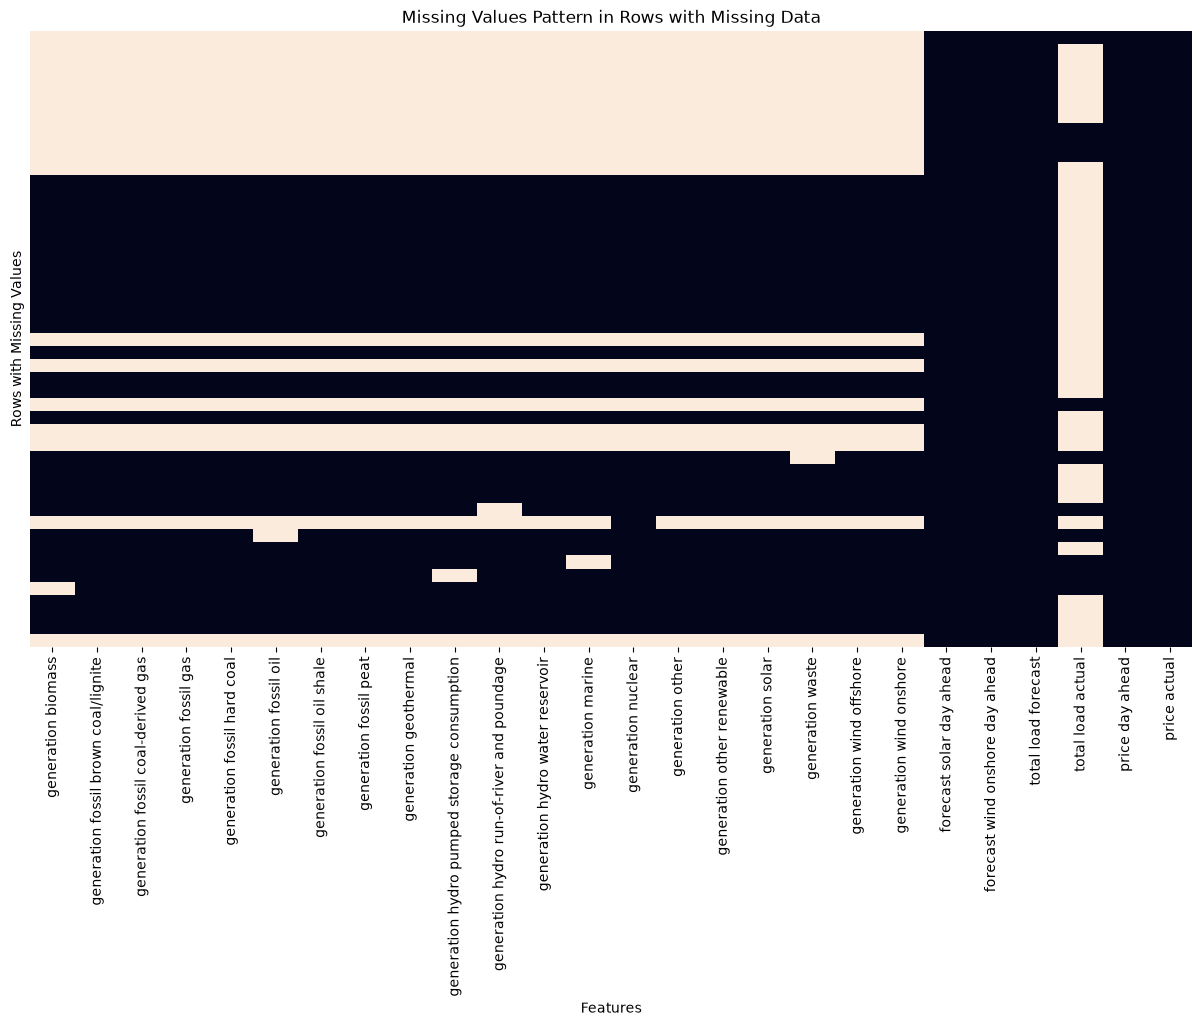

In [14]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    missing_rows.drop(columns=['time']).isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Pattern in Rows with Missing Data")
plt.xlabel("Features")
plt.ylabel("Rows with Missing Values")
plt.show()

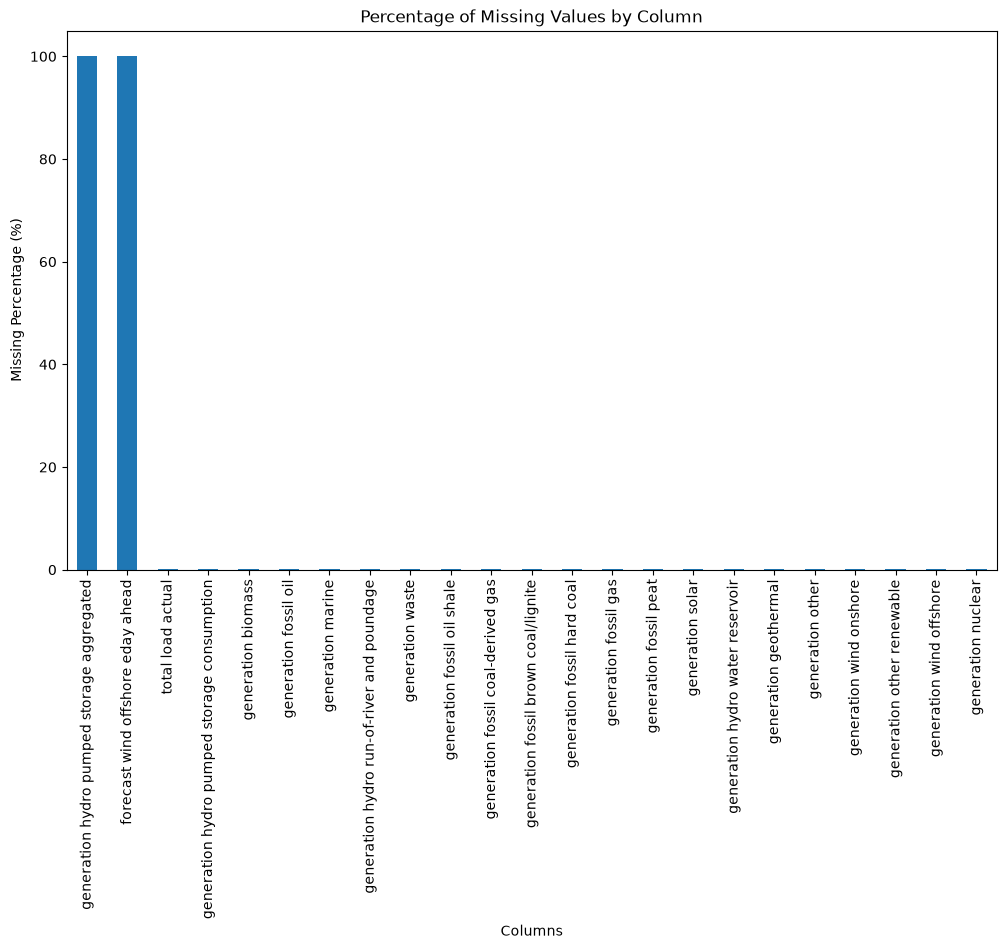

In [15]:
missing_percentage = (
    energy.isnull().sum() / len(energy) * 100
)

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

plt.figure(figsize=(12, 7))

missing_percentage.plot(kind='bar')

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)
plt.show()

-> Hình ảnh trực quan cho thấy hầu hết tập dữ liệu Năng lượng đều chứa dữ liệu đầy đủ. Hai cột, sản lượng thủy điện tích năng tổng hợp và dự báo điện gió ngoài khơi một ngày tới, có 100% giá trị bị thiếu. Đối với các cột còn lại, giá trị bị thiếu rất ít, dao động từ khoảng 0,048% đến 0,103%. Biểu đồ nhiệt cũng cho thấy các giá trị bị thiếu xuất hiện theo các mô hình khác nhau: một số xuất hiện riêng lẻ trong một cột, trong khi những giá trị khác xuất hiện đồng thời trên nhiều cột và tại các thời điểm liên tiếp.…

-> Phương pháp: Dựa trên phân tích giá trị thiếu, hai cột chứa 100% giá trị thiếu và sẽ bị loại bỏ vì chúng không cung cấp bất kỳ thông tin quan sát nào. Các giá trị thiếu còn lại có tỷ lệ rất nhỏ và xuất hiện trong dữ liệu chuỗi thời gian. Do đó, time-based interpolation sẽ được xem xét cho các biến số dạng số thay vì loại bỏ các hàng tương ứng.

1.2 Xử lý missing

In [16]:
# Xóa 2 cột bị missing 100%
energy_clean = energy.drop(columns=cols_100_missing)

print("Shape before:", energy.shape)
print("Shape after :", energy_clean.shape)

Shape before: (35064, 29)
Shape after : (35064, 27)


In [17]:
# Chuyển cột 'time' sang kiểu datetime và chuẩn hóa về UTC
energy_clean['time'] = pd.to_datetime(energy_clean['time'], utc=True)

# Sắp xếp theo thời gian
energy_clean = energy_clean.sort_values('time').reset_index(drop=True)

print(energy_clean['time'].dtype)


datetime64[us, UTC]


In [18]:
# Interpolation cho các cột số
numeric_cols = energy_clean.select_dtypes(
    include=np.number
).columns

energy_clean[numeric_cols] = (
    energy_clean[numeric_cols]
    .interpolate(method='linear')
)

In [19]:
# Check missing 
print("===== MISSING VALUES AFTER HANDLING =====")

remaining_missing = energy_clean.isnull().sum()

print(
    remaining_missing[
        remaining_missing > 0
    ]
)

print(
    "Total remaining missing values:",
    energy_clean.isnull().sum().sum()
)

===== MISSING VALUES AFTER HANDLING =====
Series([], dtype: int64)
Total remaining missing values: 0


1.3 Kiểm tra dataset sau khi xử lý

In [20]:
print("===== DATASET AFTER HANDLING MISSING VALUES =====")

print("Shape:", energy_clean.shape)

print("\nData types:")
print(energy_clean.dtypes)

===== DATASET AFTER HANDLING MISSING VALUES =====
Shape: (35064, 27)

Data types:
time                                           datetime64[us, UTC]
generation biomass                                         float64
generation fossil brown coal/lignite                       float64
generation fossil coal-derived gas                         float64
generation fossil gas                                      float64
generation fossil hard coal                                float64
generation fossil oil                                      float64
generation fossil oil shale                                float64
generation fossil peat                                     float64
generation geothermal                                      float64
generation hydro pumped storage consumption                float64
generation hydro run-of-river and poundage                 float64
generation hydro water reservoir                           float64
generation marine                              

In [21]:
# Kiểm tra interpolation 
energy_clean[
    (energy_clean['time'] >= '2015-01-05 10:00:00') &
    (energy_clean['time'] <= '2015-01-05 19:00:00')
]

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
107,2015-01-05 10:00:00+00:00,376.000000,0.0,0.0,3900.000000,2422.000000,333.000000,0.0,0.0,0.0,...,3339.000000,155.0,0.0,9131.000000,3344.0,8921.0,23271.0,24429.0,35.40,80.82
108,2015-01-05 11:00:00+00:00,375.142857,0.0,0.0,3914.714286,2392.714286,333.428571,0.0,0.0,0.0,...,3282.571429,154.0,0.0,8888.142857,3932.0,9258.0,23209.0,24066.0,35.50,79.14
109,2015-01-05 12:00:00+00:00,374.285714,0.0,0.0,3929.428571,2363.428571,333.857143,0.0,0.0,0.0,...,3226.142857,153.0,0.0,8645.285714,4236.0,9156.0,23725.0,23703.0,36.80,73.95
110,2015-01-05 13:00:00+00:00,373.428571,0.0,0.0,3944.142857,2334.142857,334.285714,0.0,0.0,0.0,...,3169.714286,152.0,0.0,8402.428571,4215.0,9072.0,23614.0,23340.0,32.50,71.93
111,2015-01-05 14:00:00+00:00,372.571429,0.0,0.0,3958.857143,2304.857143,334.714286,0.0,0.0,0.0,...,3113.285714,151.0,0.0,8159.571429,4050.0,8779.0,22381.0,22977.0,30.00,71.50
112,2015-01-05 15:00:00+00:00,371.714286,0.0,0.0,3973.571429,2275.571429,335.142857,0.0,0.0,0.0,...,3056.857143,150.0,0.0,7916.714286,3728.0,8426.0,21371.0,22614.0,30.00,71.85
113,2015-01-05 16:00:00+00:00,370.857143,0.0,0.0,3988.285714,2246.285714,335.571429,0.0,0.0,0.0,...,3000.428571,149.0,0.0,7673.857143,3175.0,7946.0,20760.0,22251.0,30.60,80.53
114,2015-01-05 17:00:00+00:00,370.000000,0.0,0.0,4003.000000,2217.000000,336.000000,0.0,0.0,0.0,...,2944.000000,148.0,0.0,7431.000000,2658.0,7617.0,20654.0,21888.0,42.01,89.08
115,2015-01-05 18:00:00+00:00,375.000000,0.0,0.0,4181.000000,2541.000000,333.000000,0.0,0.0,0.0,...,1971.000000,147.0,0.0,6570.000000,1764.0,6837.0,20904.0,22048.0,51.40,90.97
116,2015-01-05 19:00:00+00:00,371.000000,0.0,0.0,4607.000000,2509.000000,334.000000,0.0,0.0,0.0,...,958.000000,153.0,0.0,5549.000000,946.0,5836.0,22334.0,22858.0,55.35,88.51


In [22]:
# Kiểm tra giá trị lỗi
print("Minimum value of each numerical column:")

print(
    energy_clean[numeric_cols]
    .min()
    .sort_values()
)

Minimum value of each numerical column:
generation biomass                                 0.00
generation fossil brown coal/lignite               0.00
generation fossil coal-derived gas                 0.00
generation fossil gas                              0.00
generation fossil hard coal                        0.00
generation fossil oil                              0.00
generation fossil oil shale                        0.00
generation fossil peat                             0.00
generation geothermal                              0.00
generation hydro pumped storage consumption        0.00
generation hydro run-of-river and poundage         0.00
generation hydro water reservoir                   0.00
generation marine                                  0.00
generation nuclear                                 0.00
generation other                                   0.00
generation other renewable                         0.00
generation solar                                   0.00
generati

Kết luận – Xử lý các giá trị thiếu

Bộ dữ liệu Năng lượng ban đầu chứa các giá trị thiếu trong 23 cột. Hai cột có 100% giá trị thiếu và đã bị loại bỏ vì chúng không chứa thông tin quan sát hữu ích nào. Các giá trị thiếu còn lại chiếm chưa đến 0,11% bộ dữ liệu và chủ yếu xuất hiện trong các biến chuỗi thời gian dạng số.

Sau khi phân tích các mẫu giá trị thiếu, phương pháp nội suy tuyến tính được áp dụng cho các giá trị số bị thiếu còn lại. Tập dữ liệu cũng được sắp xếp theo thời gian trước khi nội suy. Sau khi xử lý, tập dữ liệu không còn giá trị thiếu nào và giữ lại 35.064 hàng và 27 cột . Kiểm định cuối cùng cho thấy không có giá trị âm nào được đưa vào các biến số.

File weather kiểm tra do không có missing nên vẫn giữ nguyên.

## 1.4 Removing Duplicates

Ngoài missing values, cần kiểm tra các bản ghi trùng lặp để tránh làm sai lệch thống kê và mô hình hóa sau này. Hai mức kiểm tra được thực hiện:

- **Duplicate hoàn toàn:** tất cả các cột đều giống nhau.
- **Trùng khóa `(dt_iso, city_name)`:** cùng thời điểm và thành phố nhưng các thuộc tính thời tiết khác có thể khác nhau.

Trong dữ liệu Weather có **21 dòng trùng hoàn toàn**. Đây là các bản ghi có thể loại bỏ trực tiếp.


In [23]:
# Kiểm tra các dòng trùng hoàn toàn trong Weather
print("Exact duplicate rows:", weather.duplicated().sum())

# Kiểm tra các bản ghi trùng khóa (dt_iso, city_name)
duplicate_key_rows = weather.duplicated(
    subset=['dt_iso', 'city_name'],
    keep='first'
).sum()

duplicate_key_group_rows = weather.duplicated(
    subset=['dt_iso', 'city_name'],
    keep=False
).sum()

duplicate_key_groups = (
    weather.groupby(['dt_iso', 'city_name'])
    .size()
    .gt(1)
    .sum()
)

print("Rows duplicated by (dt_iso, city_name):", duplicate_key_rows)
print("Rows belonging to duplicated key groups:", duplicate_key_group_rows)
print("Number of duplicated key groups:", duplicate_key_groups)


Exact duplicate rows: 21
Rows duplicated by (dt_iso, city_name): 3076
Rows belonging to duplicated key groups: 5874
Number of duplicated key groups: 2798


### Phân biệt duplicate hoàn toàn và trùng `(dt_iso, city_name)`

Kết quả cho thấy có **3.076 dòng được xác định là bản ghi lặp theo khóa `(dt_iso, city_name)` nếu giữ lại bản ghi xuất hiện đầu tiên**. Tổng cộng có **5.874 dòng** thuộc các nhóm có trùng khóa, tương ứng với **2.798 nhóm khóa**.

Tuy nhiên, việc trùng `dt_iso` và `city_name` không có nghĩa tất cả các dòng trong nhóm đều là duplicate hoàn toàn, vì các thuộc tính thời tiết khác có thể khác nhau giữa các bản ghi. Điều này có thể xảy ra khi nhiều thông tin hoặc điều kiện thời tiết được ghi nhận tại cùng một thời điểm và cùng một thành phố.

Do đó, chỉ các dòng **trùng hoàn toàn trên toàn bộ các cột** được loại bỏ. Các bản ghi có cùng `dt_iso` và `city_name` nhưng khác thông tin thời tiết được giữ lại để tránh làm mất dữ liệu.


In [24]:
# Loại bỏ các dòng trùng hoàn toàn trong Weather
weather_clean = weather.drop_duplicates().copy()

print("Shape before:", weather.shape)
print("Shape after :", weather_clean.shape)
print("Exact duplicates after removal:",
      weather_clean.duplicated().sum())


Shape before: (178396, 17)
Shape after : (178375, 17)
Exact duplicates after removal: 0


## 1.5 Drop Constant Features

Các biến có cùng một giá trị ở tất cả các quan sát không cung cấp thông tin biến thiên cho quá trình phân tích hoặc mô hình hóa. Vì vậy, các **constant features** được xác định sau bước xử lý missing values và loại bỏ.

Trong tập Energy có 6 cột constant với giá trị bằng 0:
- `generation fossil coal-derived gas`
- `generation fossil oil shale`
- `generation fossil peat`
- `generation geothermal`
- `generation marine`
- `generation wind offshore`


In [25]:
# Xác định các constant features sau khi xử lý missing values
constant_cols = [
    col for col in energy_clean.columns
    if energy_clean[col].nunique(dropna=False) <= 1
]

print("Constant features:")
print(constant_cols)

print("\nNumber of constant features:", len(constant_cols))


Constant features:
['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation marine', 'generation wind offshore']

Number of constant features: 6


In [26]:
# Loại bỏ các constant features
energy_clean = energy_clean.drop(
    columns=constant_cols
).copy()

print("Shape after dropping constant features:",
      energy_clean.shape)

remaining_constant_cols = [
    col for col in energy_clean.columns
    if energy_clean[col].nunique(dropna=False) <= 1
]

print("\nRemaining constant features:", remaining_constant_cols)


Shape after dropping constant features: (35064, 21)

Remaining constant features: []


### Kết luận

21 dòng trùng hoàn toàn trong Weather đã được loại bỏ. Các bản ghi trùng `(dt_iso, city_name)` nhưng có thông tin thời tiết khác nhau được giữ lại vì chưa đủ cơ sở để xem chúng là duplicate.

Trong Energy, 6 constant features không có biến thiên đã được loại bỏ. Các bước này giúp giảm dữ liệu dư thừa trước khi tiếp tục phân tích outliers.


2. HANDLING OUTLIERS

2.1 Xác định các biến số


In [27]:
numeric_cols = energy_clean.select_dtypes(include=np.number).columns

print("Number of numerical variables:", len(numeric_cols))
print("\nNumerical variables:")
print(numeric_cols.tolist())

Number of numerical variables: 20

Numerical variables:
['generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual']


In [28]:
# Kiểm tra tập Energy
energy_clean[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
generation biomass,35064.0,383.531343,85.346266,0.00,333.0000,367.00,433.00,592.00
generation fossil brown coal/lignite,35064.0,448.094570,354.618269,0.00,0.0000,509.00,757.00,999.00
generation fossil gas,35064.0,5622.700647,2201.510984,0.00,4126.0000,4969.50,6429.00,20034.00
generation fossil hard coal,35064.0,4256.531271,1961.988937,0.00,2527.0000,4475.00,5839.00,8359.00
generation fossil oil,35064.0,298.342417,52.519927,0.00,263.0000,300.00,330.00,449.00
generation hydro pumped storage consumption,35064.0,475.582706,792.312704,0.00,0.0000,68.00,616.00,4523.00
generation hydro run-of-river and poundage,35064.0,972.201902,400.712304,0.00,637.0000,906.00,1250.00,2000.00
generation hydro water reservoir,35064.0,2605.534123,1835.175078,0.00,1078.0000,2165.00,3758.00,9728.00
generation nuclear,35064.0,6263.483430,840.272333,0.00,5759.0000,6564.00,7025.00,7117.00
generation other,35064.0,60.226030,20.238792,0.00,53.0000,57.00,80.00,106.00


-> Cần sử dụng phương pháp IQR để xác định các giá trị ngoại lai tiềm năng, đặc biệt đối với các biến có giá trị cực đại cao hơn đáng kể so với Q3 như `generation fossil gas`, `generation wind onshore`, `generation hydro pumped storage consumption` và `generation solar`.


In [29]:
# Chọn các biến số thực sự dùng để phân tích outliers
weather_numeric_cols = weather_clean.select_dtypes(
    include=np.number
).columns.drop('weather_id')

print("Number of numerical variables:", len(weather_numeric_cols))
print("\nNumerical variables:")
print(weather_numeric_cols.tolist())


Number of numerical variables: 11

Numerical variables:
['temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all']


In [30]:
# Kiểm tra tập Weather
weather_clean[weather_numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
temp,178375.0,289.618578,8.026512,262.24,283.670,289.15,295.150,315.600
temp_min,178375.0,288.330465,7.955778,262.24,282.483,288.15,293.731,315.150
temp_max,178375.0,291.091227,8.612781,262.24,284.650,290.15,297.150,321.150
pressure,178375.0,1069.266691,5969.983260,0.00,1013.000,1018.00,1022.000,1008371.000
humidity,178375.0,68.422733,21.903495,0.00,53.000,72.00,87.000,100.000
wind_speed,178375.0,2.470688,2.095956,0.00,1.000,2.00,4.000,133.000
wind_deg,178375.0,166.592555,116.610753,0.00,55.000,177.00,270.000,360.000
rain_1h,178375.0,0.075499,0.398870,0.00,0.000,0.00,0.000,12.000
rain_3h,178375.0,0.000379,0.007285,0.00,0.000,0.00,0.000,2.315
snow_3h,178375.0,0.004763,0.222617,0.00,0.000,0.00,0.000,21.500


-> Cần sử dụng phương pháp IQR để xác định các giá trị ngoại lai tiềm năng, đặc biệt đối với các biến có phân phối hoặc khoảng giá trị bất thường như `pressure` và `wind_speed`.


2.2 Tìm Outliers bằng IQR

In [31]:
# Check file energy
outlier_summary_energy = []

for col in numeric_cols:
    Q1 = energy_clean[col].quantile(0.25)
    Q3 = energy_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = energy_clean[
        (energy_clean[col] < lower_bound) |
        (energy_clean[col] > upper_bound)
    ]

    outlier_summary_energy.append({
        'variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percentage': len(outliers) / len(energy_clean) * 100
    })

outlier_summary_energy = pd.DataFrame(outlier_summary_energy)

outlier_summary_energy.sort_values(
    'outlier_count',
    ascending=False
)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
5,generation hydro pumped storage consumption,0.0000,616.00,616.0000,-924.00000,1540.00000,3763,10.731805
2,generation fossil gas,4126.0000,6429.00,2303.0000,671.50000,9883.50000,2185,6.231462
9,generation other,53.0000,80.00,27.0000,12.50000,120.50000,1267,3.613393
18,price day ahead,41.4900,60.53,19.0400,12.93000,89.09000,841,2.398471
19,price actual,49.3475,68.01,18.6625,21.35375,96.00375,699,1.993498
15,forecast wind onshore day ahead,2979.0000,7353.00,4374.0000,-3582.00000,13914.00000,436,1.243441
13,generation wind onshore,2933.0000,7399.50,4466.5000,-3766.75000,14099.25000,377,1.075177
7,generation hydro water reservoir,1078.0000,3758.00,2680.0000,-2942.00000,7778.00000,341,0.972507
12,generation waste,240.0000,310.00,70.0000,135.00000,415.00000,328,0.935432
4,generation fossil oil,263.0000,330.00,67.0000,162.50000,430.50000,246,0.701574


In [32]:
# Phân tích outliers bằng IQR cho tập Weather
outlier_summary_weather = []

for col in weather_numeric_cols:
    Q1 = weather_clean[col].quantile(0.25)
    Q3 = weather_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = weather_clean[
        (weather_clean[col] < lower_bound) |
        (weather_clean[col] > upper_bound)
    ]

    outlier_summary_weather.append({
        'variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percentage': len(outliers) / len(weather_clean) * 100
    })

outlier_summary_weather = pd.DataFrame(outlier_summary_weather)

outlier_summary_weather.sort_values(
    'outlier_percentage',
    ascending=False
)


,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
7,rain_1h,0.000,0.000,0.000,0.000,0.000,19387,10.868676
3,pressure,1013.000,1022.000,9.000,999.500,1035.500,11829,6.631535
5,wind_speed,1.000,4.000,3.000,-3.500,8.500,2425,1.359495
8,rain_3h,0.000,0.000,0.000,0.000,0.000,1854,1.039383
2,temp_max,284.650,297.150,12.500,265.900,315.900,391,0.219201
1,temp_min,282.483,293.731,11.248,265.611,310.603,290,0.162579
9,snow_3h,0.000,0.000,0.000,0.000,0.000,267,0.149685
0,temp,283.670,295.150,11.480,266.450,312.370,196,0.109881
4,humidity,53.000,87.000,34.000,2.000,138.000,63,0.035319
6,wind_deg,55.000,270.000,215.000,-267.500,592.500,0,0.000000


-> Phân tích IQR cho thấy tỷ lệ ngoại lai tiềm năng đáng kể ở một số biến, tiêu biểu như `generation hydro pumped storage consumption` (10,73%), `generation fossil gas` (6,23%) ở tập Energy và `rain_1h` (10,87%), `pressure` (6,63%) ở tập Weather. Tuy nhiên, IQR chỉ đo lường mức độ lệch về mặt thống kê chứ không khẳng định dữ liệu bị sai. Các giá trị cực đoan có thể là hiện tượng thực tế hoặc do đặc điểm phân phối. Do đó, cần trực quan hóa bằng Boxplot và kiểm tra ý nghĩa thực tế trước khi quyết định xử lý.


2.3 Visualize Outliers

In [33]:
energy_outlier_cols = [
    'generation hydro pumped storage consumption',
    'generation fossil gas',
    'generation other',
    'price day ahead',
    'price actual',
    'generation wind onshore'
]

weather_outlier_cols = [
    'pressure',
    'wind_speed',
    'rain_1h',
    'rain_3h',
    'snow_3h'
]

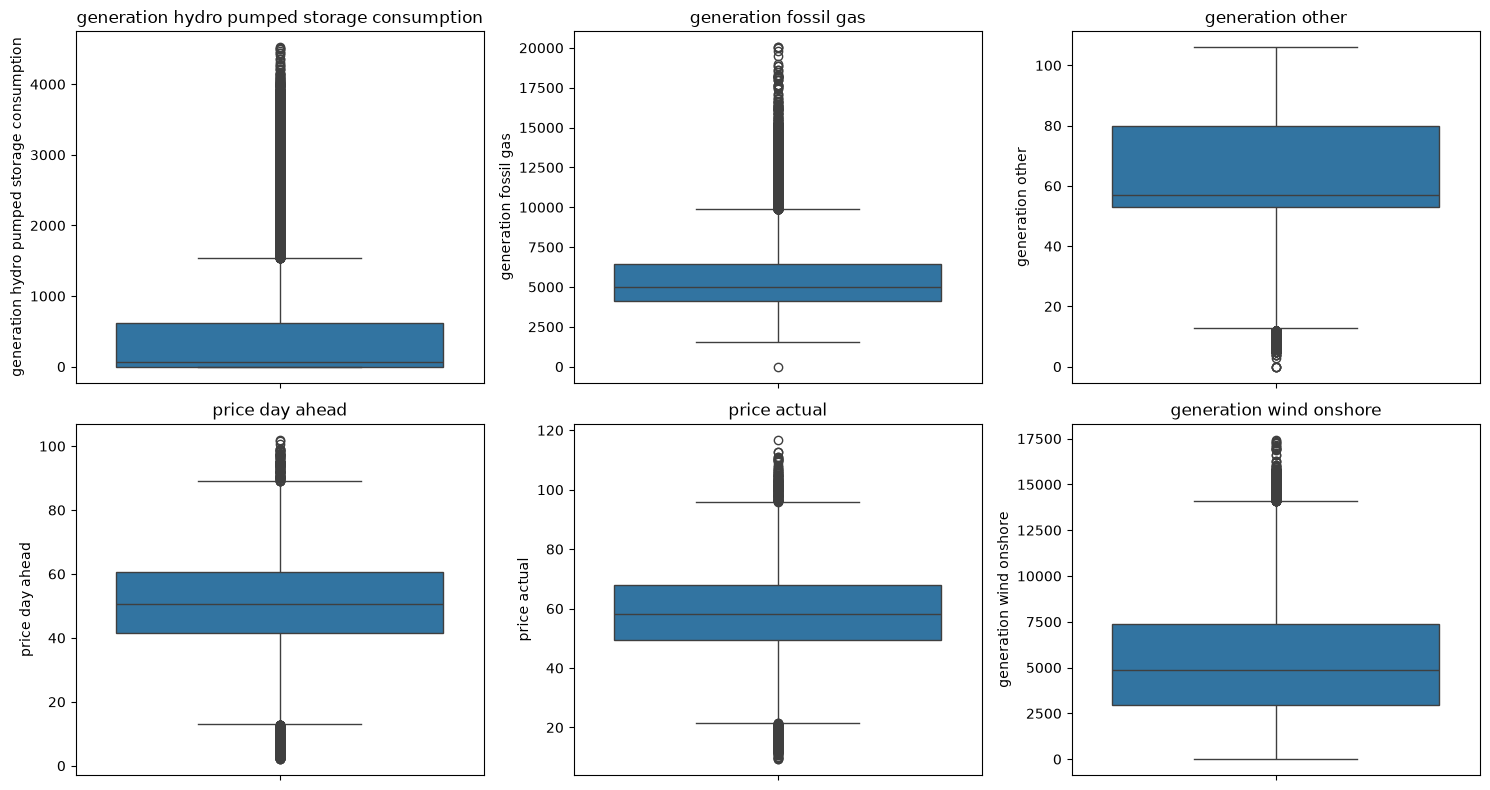

In [34]:
# Vẽ bảng energy outliers
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

for ax, col in zip(axes.flatten(), energy_outlier_cols):
    sns.boxplot(y=energy_clean[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

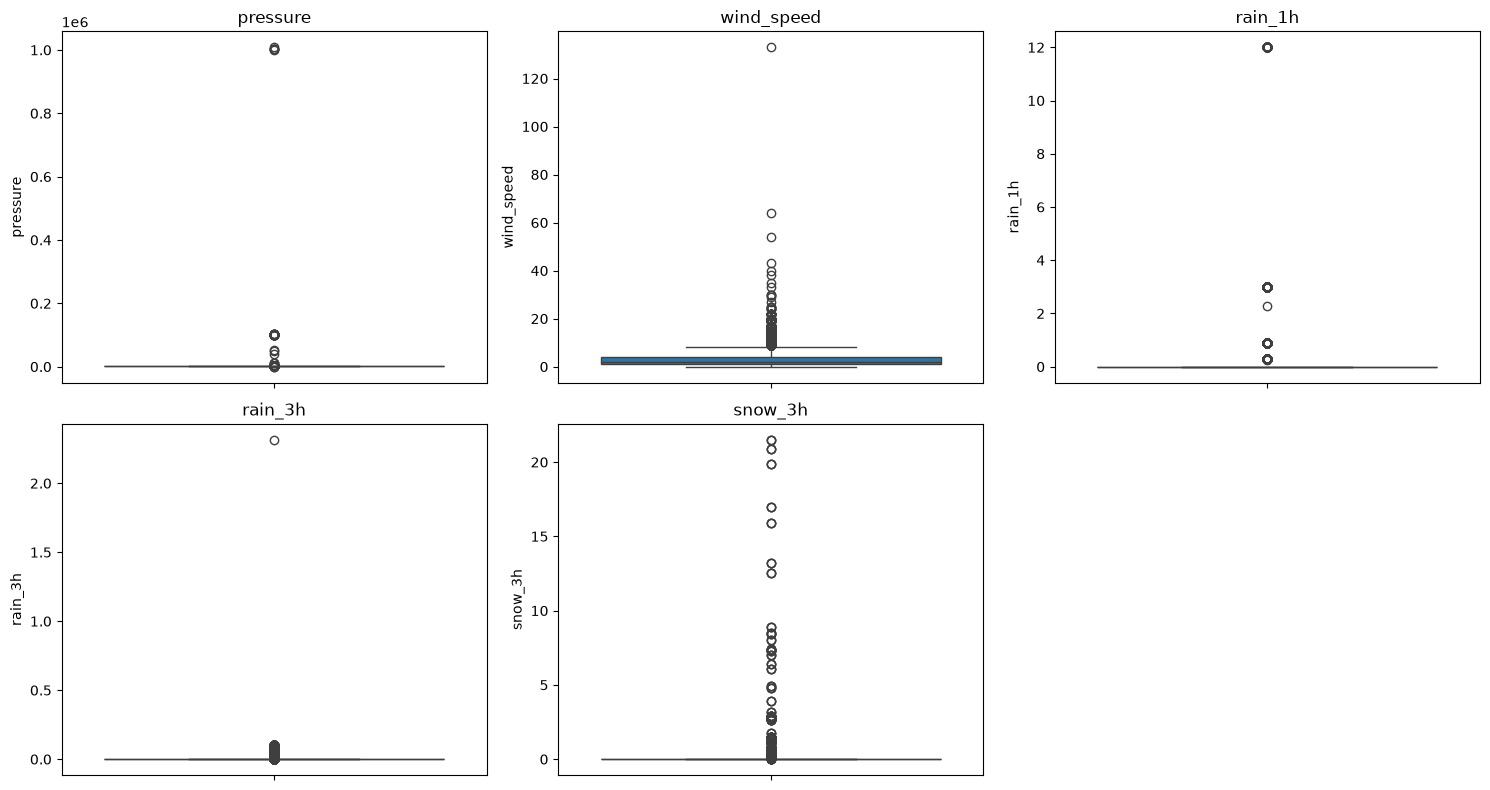

In [35]:
# Vẽ boxplot các biến Weather có nhiều potential outliers
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

for ax, col in zip(axes.flatten(), weather_outlier_cols):
    sns.boxplot(y=weather_clean[col], ax=ax)
    ax.set_title(col)

# Ẩn ô thừa
for ax in axes.flatten()[len(weather_outlier_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


-> Biểu đồ boxplot cho thấy ngoại lai ở hai tập dữ liệu có bản chất khác nhau: các biến năng lượng (fossil gas, hydro pumped storage) chủ yếu bị lệch phải do tải cao, trong khi biến giá cả có ngoại lai ở cả hai đầu. Với tập Weather, pressure có những giá trị cực đoan tách biệt hẳn (nghi vấn lỗi đo), còn lượng mưa và tuyết tập trung phần lớn ở mốc 0 khiến các lần có mưa đều bị IQR nhận nhầm là ngoại lai. Do đó, ngoại lai thống kê chưa hẳn là dữ liệu sai; cần đối chiếu ý nghĩa thực tế của từng biến trước khi quyết định phương án xử lý.

### 2.4 Phân tích Outliers

- **Nhóm 1 – Dấu hiệu bất thường về chất lượng dữ liệu**
  - `pressure`: xuất hiện một số giá trị chênh lệch rất lớn so với phân phối chính, có khả năng là lỗi nhập liệu hoặc lỗi đo lường.
  - `wind_speed`: xuất hiện một số giá trị cực đoan cần được kiểm tra thêm dựa trên chuỗi thời gian.

- **Nhóm 2 – Giá trị cực đoan nhưng có thể hợp lệ**
  - Một số biến trong tập Energy có các giá trị cao được IQR xác định là outlier. Tuy nhiên, các giá trị này có thể phản ánh những thời điểm sản xuất hoặc tiêu thụ điện cao trong thực tế, do đó không nên loại bỏ tự động.

- **Nhóm 3 – Giá trị hiếm nhưng có ý nghĩa thực tế**
  - Các biến như `rain_1h`, `rain_3h` và `snow_3h` có nhiều giá trị bằng 0, trong khi các giá trị dương tương đối hiếm. Những giá trị này vẫn có thể đại diện cho các hiện tượng thời tiết thực tế.

- **Nhóm 4 – Biến mã hóa phân loại**
  - `weather_id` là mã định danh cho nhóm thời tiết nên không được xem là biến đo lường liên tục để xử lý outlier bằng IQR.

- **Nhóm 5 – Các biến phản ánh biến động tự nhiên**
  - Một số biến về sản lượng và giá điện có thể biến động mạnh theo điều kiện vận hành và thị trường. Vì vậy, các giá trị cực đoan không nhất thiết là dữ liệu lỗi.


2.5 Chọn phương pháp xử lý ngoại lệ

Dựa trên phân tích ngoại lai, các chiến lược xử lý khác nhau sẽ được áp dụng cho từng nhóm biến riêng biệt. Các quan sát bất thường nghiêm trọng ở biến `pressure` và `wind_speed` sẽ được kiểm tra tiếp, bởi chúng nằm quá xa phân phối chính và có khả năng phản ánh lỗi về chất lượng dữ liệu. Do bộ dữ liệu Weather mang đặc tính chuỗi thời gian, phương pháp nội suy theo thời gian có thể được sử dụng để thay thế các giá trị được xác nhận là lỗi, đồng thời vẫn bảo toàn số lượng quan sát sau bước loại bỏ duplicate hoàn toàn.

Đối với các biến sản lượng phát điện và giá điện, các quan sát cực đoan được phát hiện sẽ được giữ nguyên vì chúng có thể đại diện cho những biến động thực tế hợp lệ. Tương tự, các giá trị dương ở `rain_1h`, `rain_3h` và `snow_3h` cũng được giữ lại vì chúng biểu thị các hiện tượng thời tiết có thật. Biến `weather_id` được loại trừ khỏi quy trình xử lý ngoại lai dựa trên IQR do đây là biến mã hóa phân loại thay vì một đại lượng đo lường liên tục.


2.6 Xử lý ngoại lệ

In [36]:
# Tạo bản sao từ dữ liệu Weather đã loại bỏ duplicate hoàn toàn
weather_outlier_clean = weather_clean.copy()

print("Shape after duplicate removal:", weather_outlier_clean.shape)
print("Exact duplicates:", weather_outlier_clean.duplicated().sum())


Shape after duplicate removal: (178375, 17)
Exact duplicates: 0


In [37]:
# Xác định các giá trị ngoại lai tiềm năng bằng phương pháp IQR

# Pressure
Q1_pressure = weather_outlier_clean['pressure'].quantile(0.25)
Q3_pressure = weather_outlier_clean['pressure'].quantile(0.75)
IQR_pressure = Q3_pressure - Q1_pressure

pressure_lower = Q1_pressure - 1.5 * IQR_pressure
pressure_upper = Q3_pressure + 1.5 * IQR_pressure


# Wind speed
Q1_wind = weather_outlier_clean['wind_speed'].quantile(0.25)
Q3_wind = weather_outlier_clean['wind_speed'].quantile(0.75)
IQR_wind = Q3_wind - Q1_wind

wind_lower = Q1_wind - 1.5 * IQR_wind
wind_upper = Q3_wind + 1.5 * IQR_wind


print("=== IQR Boundaries ===")

print("\nPressure:")
print("Q1:", Q1_pressure)
print("Q3:", Q3_pressure)
print("IQR:", IQR_pressure)
print("Lower bound:", pressure_lower)
print("Upper bound:", pressure_upper)

print("\nWind speed:")
print("Q1:", Q1_wind)
print("Q3:", Q3_wind)
print("IQR:", IQR_wind)
print("Lower bound:", wind_lower)
print("Upper bound:", wind_upper)

=== IQR Boundaries ===

Pressure:
Q1: 1013.0
Q3: 1022.0
IQR: 9.0
Lower bound: 999.5
Upper bound: 1035.5

Wind speed:
Q1: 1.0
Q3: 4.0
IQR: 3.0
Lower bound: -3.5
Upper bound: 8.5


In [38]:
# Xác định các giá trị ngoại lai tiềm năng

pressure_outliers = (
    (weather_outlier_clean['pressure'] < pressure_lower) |
    (weather_outlier_clean['pressure'] > pressure_upper)
)

wind_outliers = (
    (weather_outlier_clean['wind_speed'] < wind_lower) |
    (weather_outlier_clean['wind_speed'] > wind_upper)
)

print("Potential pressure outliers:", pressure_outliers.sum())
print("Potential wind speed outliers:", wind_outliers.sum())

Potential pressure outliers: 11829
Potential wind speed outliers: 2425


In [39]:
# Chuyển thời gian và sắp xếp để nội suy theo từng thành phố
weather_outlier_clean['dt_iso'] = pd.to_datetime(
    weather_outlier_clean['dt_iso'],
    utc=True
)

weather_outlier_clean = weather_outlier_clean.sort_values(
    ['city_name', 'dt_iso']
).reset_index(drop=True)


In [40]:
# Giữ bản sao Energy sau khi xử lý missing values và constant features
energy_outlier_clean = energy_clean.copy()


In [41]:
# Kiểm tra các giá trị pressure lớn và potential outliers

print("Pressure:")
print("Min:", weather_outlier_clean['pressure'].min())
print("Max:", weather_outlier_clean['pressure'].max())
print("Upper bound (1.5×IQR):", pressure_upper)

print("\nNumber > upper bound:",
      (weather_outlier_clean['pressure'] > pressure_upper).sum())

print("\nSome largest pressure values:")
print(
    weather_outlier_clean.nlargest(20, 'pressure')[[
        'dt_iso', 'city_name', 'pressure'
    ]]
)


Pressure:
Min: 0
Max: 1008371
Upper bound (1.5×IQR): 1035.5

Number > upper bound: 1804

Some largest pressure values:
                        dt_iso   city_name  pressure
1226 2015-02-21 01:00:00+00:00   Barcelona   1008371
1256 2015-02-22 07:00:00+00:00   Barcelona   1002881
1255 2015-02-22 06:00:00+00:00   Barcelona   1002241
1233 2015-02-21 08:00:00+00:00   Barcelona   1001781
1234 2015-02-21 09:00:00+00:00   Barcelona   1001501
1235 2015-02-21 10:00:00+00:00   Barcelona   1000951
1209 2015-02-20 08:00:00+00:00   Barcelona    102153
1210 2015-02-20 09:00:00+00:00   Barcelona    102132
1211 2015-02-20 10:00:00+00:00   Barcelona    102075
1212 2015-02-20 11:00:00+00:00   Barcelona    101983
1213 2015-02-20 12:00:00+00:00   Barcelona    101921
1214 2015-02-20 13:00:00+00:00   Barcelona    101756
1216 2015-02-20 15:00:00+00:00   Barcelona    101574
1221 2015-02-20 20:00:00+00:00   Barcelona    101338
1222 2015-02-20 21:00:00+00:00   Barcelona    101324
1223 2015-02-20 22:00:00+00:00   

In [42]:
print("\nWind speed:")
print("Min:", weather_outlier_clean['wind_speed'].min())
print("Max:", weather_outlier_clean['wind_speed'].max())
print("Upper bound (1.5×IQR):", wind_upper)

print("\nNumber > upper bound:",
      (weather_outlier_clean['wind_speed'] > wind_upper).sum())

print("\nSome largest wind speed values:")
print(
    weather_outlier_clean.nlargest(20, 'wind_speed')[[
        'dt_iso', 'city_name', 'wind_speed'
    ]]
)



Wind speed:
Min: 0
Max: 133
Upper bound (1.5×IQR): 8.5

Number > upper bound: 2425

Some largest wind speed values:
                          dt_iso city_name  wind_speed
163957 2017-05-11 10:00:00+00:00  Valencia         133
143942 2015-01-30 10:00:00+00:00  Valencia          64
143946 2015-01-30 14:00:00+00:00  Valencia          54
144529 2015-02-23 21:00:00+00:00  Valencia          43
143947 2015-01-30 15:00:00+00:00  Valencia          40
143950 2015-01-30 18:00:00+00:00  Valencia          38
143934 2015-01-30 02:00:00+00:00  Valencia          35
143941 2015-01-30 09:00:00+00:00  Valencia          33
143608 2015-01-16 12:00:00+00:00  Valencia          30
143921 2015-01-29 13:00:00+00:00  Valencia          30
143951 2015-01-30 19:00:00+00:00  Valencia          30
144528 2015-02-23 20:00:00+00:00  Valencia          29
143606 2015-01-16 10:00:00+00:00  Valencia          27
143537 2015-01-13 13:00:00+00:00  Valencia          25
144065 2015-02-04 13:00:00+00:00  Valencia          25
144

In [43]:
# Kiểm tra các pressure potential outliers theo thành phố

pressure_high = weather_outlier_clean[
    weather_outlier_clean['pressure'] > pressure_upper
]

print("Số pressure potential outliers:", len(pressure_high))

print("\nPhân bố theo thành phố:")
print(pressure_high['city_name'].value_counts())

print("\nKhoảng pressure theo từng thành phố:")
print(
    pressure_high.groupby('city_name')['pressure']
    .agg(['count', 'min', 'max'])
    .sort_values('count', ascending=False)
)


Số pressure potential outliers: 1804

Phân bố theo thành phố:
city_name
Bilbao        569
Valencia      514
Seville       353
 Barcelona    237
Madrid        131
Name: count, dtype: int64

Khoảng pressure theo từng thành phố:
            count   min      max
city_name                       
Bilbao        569  1036     1042
Valencia      514  1036     1087
Seville       353  1036     1090
 Barcelona    237  1036  1008371
Madrid        131  1036     1042


In [44]:
# Kiểm tra trực tiếp các pressure potential outliers ở Barcelona

barcelona_pressure = weather_outlier_clean[
    (weather_outlier_clean['city_name'] == 'Barcelona') &
    (weather_outlier_clean['pressure'] > pressure_upper)
].sort_values('dt_iso')

print("Số giá trị:", len(barcelona_pressure))

print(
    barcelona_pressure[
        ['dt_iso', 'city_name', 'pressure']
    ].to_string(index=False)
)


Số giá trị: 0
Empty DataFrame
Columns: [dt_iso, city_name, pressure]
Index: []


In [45]:
print("Shape:", weather_outlier_clean.shape)

print("\nCác city_name hiện có:")
print(weather_outlier_clean['city_name'].unique())

print("\nCác dòng pressure > IQR upper bound:")
print(
    weather_outlier_clean.loc[
        weather_outlier_clean['pressure'] > pressure_upper,
        ['dt_iso', 'city_name', 'pressure']
    ].head(20).to_string(index=False)
)

print("\nSố dòng pressure > IQR upper bound:",
      (weather_outlier_clean['pressure'] > pressure_upper).sum())


Shape: (178375, 17)

Các city_name hiện có:
<StringArray>
[' Barcelona', 'Bilbao', 'Madrid', 'Seville', 'Valencia']
Length: 5, dtype: str

Các dòng pressure > IQR upper bound:
                   dt_iso  city_name  pressure
2015-01-01 01:00:00+00:00  Barcelona      1036
2015-01-01 02:00:00+00:00  Barcelona      1036
2015-01-01 03:00:00+00:00  Barcelona      1036
2015-01-01 04:00:00+00:00  Barcelona      1037
2015-01-01 05:00:00+00:00  Barcelona      1037
2015-01-01 06:00:00+00:00  Barcelona      1037
2015-01-01 07:00:00+00:00  Barcelona      1038
2015-01-01 08:00:00+00:00  Barcelona      1038
2015-01-01 09:00:00+00:00  Barcelona      1038
2015-01-01 10:00:00+00:00  Barcelona      1038
2015-01-01 11:00:00+00:00  Barcelona      1038
2015-01-01 12:00:00+00:00  Barcelona      1038
2015-01-01 18:00:00+00:00  Barcelona      1036
2015-01-01 19:00:00+00:00  Barcelona      1036
2015-01-01 20:00:00+00:00  Barcelona      1038
2015-01-01 21:00:00+00:00  Barcelona      1038
2015-01-01 22:00:00+00:00

In [46]:
# Remove leading/trailing spaces from city names

weather_outlier_clean['city_name'] = (
    weather_outlier_clean['city_name'].str.strip()
)

print(weather_outlier_clean['city_name'].unique())

<StringArray>
['Barcelona', 'Bilbao', 'Madrid', 'Seville', 'Valencia']
Length: 5, dtype: str


In [47]:
# Check potential pressure outliers in Barcelona

barcelona_pressure = weather_outlier_clean[
    (weather_outlier_clean['city_name'] == 'Barcelona') &
    (weather_outlier_clean['pressure'] > pressure_upper)
].sort_values('dt_iso')

print("Số giá trị:", len(barcelona_pressure))

print(
    barcelona_pressure[
        ['dt_iso', 'city_name', 'pressure']
    ].to_string(index=False)
)

Số giá trị: 237
                   dt_iso city_name  pressure
2015-01-01 01:00:00+00:00 Barcelona      1036
2015-01-01 02:00:00+00:00 Barcelona      1036
2015-01-01 03:00:00+00:00 Barcelona      1036
2015-01-01 04:00:00+00:00 Barcelona      1037
2015-01-01 05:00:00+00:00 Barcelona      1037
2015-01-01 06:00:00+00:00 Barcelona      1037
2015-01-01 07:00:00+00:00 Barcelona      1038
2015-01-01 08:00:00+00:00 Barcelona      1038
2015-01-01 09:00:00+00:00 Barcelona      1038
2015-01-01 10:00:00+00:00 Barcelona      1038
2015-01-01 11:00:00+00:00 Barcelona      1038
2015-01-01 12:00:00+00:00 Barcelona      1038
2015-01-01 18:00:00+00:00 Barcelona      1036
2015-01-01 19:00:00+00:00 Barcelona      1036
2015-01-01 20:00:00+00:00 Barcelona      1038
2015-01-01 21:00:00+00:00 Barcelona      1038
2015-01-01 22:00:00+00:00 Barcelona      1038
2015-01-01 23:00:00+00:00 Barcelona      1038
2015-01-02 00:00:00+00:00 Barcelona      1038
2015-01-02 01:00:00+00:00 Barcelona      1037
2015-01-02 02:00:0

In [48]:
# RESET: tạo lại dataset từ dữ liệu đã loại bỏ duplicate hoàn toàn trước khi xử lý outliers

weather_outlier_clean = weather_clean.copy()

# Chuẩn hóa tên thành phố
weather_outlier_clean['city_name'] = (
    weather_outlier_clean['city_name'].str.strip()
)

# Chuyển thời gian sang datetime
weather_outlier_clean['dt_iso'] = pd.to_datetime(
    weather_outlier_clean['dt_iso'],
    utc=True
)

# Sắp xếp theo thành phố và thời gian
weather_outlier_clean = (
    weather_outlier_clean
    .sort_values(['city_name', 'dt_iso'])
    .reset_index(drop=True)
)

print("weather original shape:", weather.shape)
print("weather after duplicate removal:", weather_clean.shape)
print("weather_outlier_clean shape:", weather_outlier_clean.shape)

print("\nExact duplicates:")
print(weather_outlier_clean.duplicated().sum())

print("\nPressure max:")
print(weather_outlier_clean['pressure'].max())

print("\nPressure min:")
print(weather_outlier_clean['pressure'].min())

print("\nCity names:")
print(weather_outlier_clean['city_name'].unique())


weather original shape: (178396, 17)
weather after duplicate removal: (178375, 17)
weather_outlier_clean shape: (178375, 17)

Exact duplicates:
0

Pressure max:
1008371

Pressure min:
0

City names:
<StringArray>
['Barcelona', 'Bilbao', 'Madrid', 'Seville', 'Valencia']
Length: 5, dtype: str


In [49]:
# Kiểm tra các giá trị pressure bất thường

pressure_check = weather_outlier_clean[
    (weather_outlier_clean['pressure'] <= 0) |
    (weather_outlier_clean['pressure'] > 1100)
].copy()

print("Số giá trị pressure <= 0:", 
      (weather_outlier_clean['pressure'] <= 0).sum())

print("Số giá trị pressure > 1100:", 
      (weather_outlier_clean['pressure'] > 1100).sum())

print("\nPhân bố theo thành phố:")
print(pressure_check['city_name'].value_counts())

print("\nMột số giá trị pressure lớn nhất:")
print(
    pressure_check
    .nlargest(30, 'pressure')[
        ['dt_iso', 'city_name', 'pressure']
    ]
    .to_string(index=False)
)

Số giá trị pressure <= 0: 2
Số giá trị pressure > 1100: 45

Phân bố theo thành phố:
city_name
Barcelona    47
Name: count, dtype: int64

Một số giá trị pressure lớn nhất:
                   dt_iso city_name  pressure
2015-02-21 01:00:00+00:00 Barcelona   1008371
2015-02-22 07:00:00+00:00 Barcelona   1002881
2015-02-22 06:00:00+00:00 Barcelona   1002241
2015-02-21 08:00:00+00:00 Barcelona   1001781
2015-02-21 09:00:00+00:00 Barcelona   1001501
2015-02-21 10:00:00+00:00 Barcelona   1000951
2015-02-20 08:00:00+00:00 Barcelona    102153
2015-02-20 09:00:00+00:00 Barcelona    102132
2015-02-20 10:00:00+00:00 Barcelona    102075
2015-02-20 11:00:00+00:00 Barcelona    101983
2015-02-20 12:00:00+00:00 Barcelona    101921
2015-02-20 13:00:00+00:00 Barcelona    101756
2015-02-20 15:00:00+00:00 Barcelona    101574
2015-02-20 20:00:00+00:00 Barcelona    101338
2015-02-20 21:00:00+00:00 Barcelona    101324
2015-02-20 22:00:00+00:00 Barcelona    101162
2015-02-20 23:00:00+00:00 Barcelona    101061
2

In [50]:
barcelona_pressure = weather_outlier_clean[
    weather_outlier_clean['city_name'].str.strip().eq('Barcelona') &
    (
        (weather_outlier_clean['pressure'] <= 0) |
        (weather_outlier_clean['pressure'] > 1100)
    )
].copy()

print("Số dòng cần kiểm tra:", len(barcelona_pressure))

print(
    barcelona_pressure[
        ['dt_iso', 'city_name', 'pressure']
    ]
    .sort_values('dt_iso')
    .to_string(index=False)
)

Số dòng cần kiểm tra: 47
                   dt_iso city_name  pressure
2015-02-20 08:00:00+00:00 Barcelona    102153
2015-02-20 09:00:00+00:00 Barcelona    102132
2015-02-20 10:00:00+00:00 Barcelona    102075
2015-02-20 11:00:00+00:00 Barcelona    101983
2015-02-20 12:00:00+00:00 Barcelona    101921
2015-02-20 13:00:00+00:00 Barcelona    101756
2015-02-20 14:00:00+00:00 Barcelona     10163
2015-02-20 15:00:00+00:00 Barcelona    101574
2015-02-20 17:00:00+00:00 Barcelona     10145
2015-02-20 18:00:00+00:00 Barcelona     40542
2015-02-20 19:00:00+00:00 Barcelona     51177
2015-02-20 20:00:00+00:00 Barcelona    101338
2015-02-20 21:00:00+00:00 Barcelona    101324
2015-02-20 22:00:00+00:00 Barcelona    101162
2015-02-20 23:00:00+00:00 Barcelona    101061
2015-02-21 00:00:00+00:00 Barcelona    101007
2015-02-21 01:00:00+00:00 Barcelona   1008371
2015-02-21 04:00:00+00:00 Barcelona    100477
2015-02-21 05:00:00+00:00 Barcelona    100390
2015-02-21 06:00:00+00:00 Barcelona    100326
2015-02-2

In [51]:
# Kiểm tra chuỗi pressure của Barcelona quanh các giá trị bất thường
barcelona_all = (
    weather_outlier_clean[
        weather_outlier_clean['city_name'] == 'Barcelona'
    ][['dt_iso', 'pressure']]
    .sort_values('dt_iso')
)

print(
    barcelona_all[
        (barcelona_all['dt_iso'] >= '2015-02-20') &
        (barcelona_all['dt_iso'] <= '2015-02-23')
    ].to_string(index=False)
)


                   dt_iso  pressure
2015-02-20 00:00:00+00:00      1024
2015-02-20 01:00:00+00:00      1023
2015-02-20 02:00:00+00:00      1023
2015-02-20 03:00:00+00:00      1023
2015-02-20 04:00:00+00:00      1022
2015-02-20 05:00:00+00:00      1022
2015-02-20 06:00:00+00:00      1022
2015-02-20 07:00:00+00:00      1021
2015-02-20 08:00:00+00:00    102153
2015-02-20 09:00:00+00:00    102132
2015-02-20 10:00:00+00:00    102075
2015-02-20 11:00:00+00:00    101983
2015-02-20 12:00:00+00:00    101921
2015-02-20 13:00:00+00:00    101756
2015-02-20 14:00:00+00:00     10163
2015-02-20 15:00:00+00:00    101574
2015-02-20 16:00:00+00:00      1020
2015-02-20 17:00:00+00:00     10145
2015-02-20 18:00:00+00:00     40542
2015-02-20 19:00:00+00:00     51177
2015-02-20 20:00:00+00:00    101338
2015-02-20 21:00:00+00:00    101324
2015-02-20 22:00:00+00:00    101162
2015-02-20 23:00:00+00:00    101061
2015-02-21 00:00:00+00:00    101007
2015-02-21 01:00:00+00:00   1008371
2015-02-21 02:00:00+00:00   

In [52]:
# Xác định các giá trị pressure không hợp lệ
pressure_invalid = (
    (weather_outlier_clean['pressure'] < 900) |
    (weather_outlier_clean['pressure'] > 1100)
)

print("Số giá trị pressure không hợp lệ:",
      pressure_invalid.sum())

# Thay các giá trị không hợp lệ bằng NaN
weather_outlier_clean.loc[
    pressure_invalid, 'pressure'
] = np.nan

# Nội suy theo thời gian trong từng thành phố
weather_outlier_clean['pressure'] = (
    weather_outlier_clean
    .groupby('city_name', group_keys=False)
    .apply(
        lambda group: group.set_index('dt_iso')['pressure']
        .interpolate(method='time')
        .reset_index(drop=True),
        include_groups=False
    )
    .reset_index(drop=True)
)


Số giá trị pressure không hợp lệ: 48


In [53]:
print("Missing pressure sau xử lý:",
      weather_outlier_clean['pressure'].isna().sum())

print("Pressure min sau xử lý:",
      weather_outlier_clean['pressure'].min())

print("Pressure max sau xử lý:",
      weather_outlier_clean['pressure'].max())

print("\nMột số giá trị pressure sau xử lý:")
print(
    weather_outlier_clean[
        weather_outlier_clean['city_name'] == 'Barcelona'
    ][['dt_iso', 'pressure']]
    .loc[
        lambda x: x['dt_iso'].between(
            '2015-02-20',
            '2015-02-23'
        )
    ]
    .to_string(index=False)
)

Missing pressure sau xử lý: 0
Pressure min sau xử lý: 918.0
Pressure max sau xử lý: 1090.0

Một số giá trị pressure sau xử lý:
                   dt_iso    pressure
2015-02-20 00:00:00+00:00 1024.000000
2015-02-20 01:00:00+00:00 1023.000000
2015-02-20 02:00:00+00:00 1023.000000
2015-02-20 03:00:00+00:00 1023.000000
2015-02-20 04:00:00+00:00 1022.000000
2015-02-20 05:00:00+00:00 1022.000000
2015-02-20 06:00:00+00:00 1022.000000
2015-02-20 07:00:00+00:00 1021.000000
2015-02-20 08:00:00+00:00 1020.888889
2015-02-20 09:00:00+00:00 1020.777778
2015-02-20 10:00:00+00:00 1020.666667
2015-02-20 11:00:00+00:00 1020.555556
2015-02-20 12:00:00+00:00 1020.444444
2015-02-20 13:00:00+00:00 1020.333333
2015-02-20 14:00:00+00:00 1020.222222
2015-02-20 15:00:00+00:00 1020.111111
2015-02-20 16:00:00+00:00 1020.000000
2015-02-20 17:00:00+00:00 1019.200000
2015-02-20 18:00:00+00:00 1018.400000
2015-02-20 19:00:00+00:00 1017.600000
2015-02-20 20:00:00+00:00 1016.800000
2015-02-20 21:00:00+00:00 1016.000000

In [54]:
# Kiểm tra các giá trị wind_speed bất thường

print("Wind speed min:", weather_outlier_clean['wind_speed'].min())
print("Wind speed max:", weather_outlier_clean['wind_speed'].max())

print("\nMột số giá trị wind_speed lớn nhất:")
print(
    weather_outlier_clean
    .nlargest(30, 'wind_speed')[
        ['dt_iso', 'city_name', 'wind_speed']
    ]
    .to_string(index=False)
)

Wind speed min: 0
Wind speed max: 133

Một số giá trị wind_speed lớn nhất:
                   dt_iso city_name  wind_speed
2017-05-11 10:00:00+00:00  Valencia         133
2015-01-30 10:00:00+00:00  Valencia          64
2015-01-30 14:00:00+00:00  Valencia          54
2015-02-23 21:00:00+00:00  Valencia          43
2015-01-30 15:00:00+00:00  Valencia          40
2015-01-30 18:00:00+00:00  Valencia          38
2015-01-30 02:00:00+00:00  Valencia          35
2015-01-30 09:00:00+00:00  Valencia          33
2015-01-16 12:00:00+00:00  Valencia          30
2015-01-29 13:00:00+00:00  Valencia          30
2015-01-30 19:00:00+00:00  Valencia          30
2015-02-23 20:00:00+00:00  Valencia          29
2015-01-16 10:00:00+00:00  Valencia          27
2015-01-13 13:00:00+00:00  Valencia          25
2015-02-04 13:00:00+00:00  Valencia          25
2015-02-24 02:00:00+00:00  Valencia          25
2015-01-30 11:00:00+00:00  Valencia          24
2015-02-05 13:00:00+00:00  Valencia          24
2015-02-23 10

In [55]:
# Kiểm tra chuỗi thời gian xung quanh wind_speed = 133

valencia_wind = (
    weather_outlier_clean[
        weather_outlier_clean['city_name'] == 'Valencia'
    ]
    .sort_values('dt_iso')
)

check_wind = valencia_wind[
    (valencia_wind['dt_iso'] >= '2017-05-11 05:00:00+00:00') &
    (valencia_wind['dt_iso'] <= '2017-05-11 15:00:00+00:00')
]

print(
    check_wind[
        ['dt_iso', 'wind_speed']
    ].to_string(index=False)
)

                   dt_iso  wind_speed
2017-05-11 05:00:00+00:00           2
2017-05-11 06:00:00+00:00           3
2017-05-11 07:00:00+00:00           5
2017-05-11 08:00:00+00:00           4
2017-05-11 09:00:00+00:00          10
2017-05-11 10:00:00+00:00         133
2017-05-11 11:00:00+00:00          12
2017-05-11 12:00:00+00:00          11
2017-05-11 13:00:00+00:00          12
2017-05-11 14:00:00+00:00          10
2017-05-11 15:00:00+00:00           8


In [56]:
# Xác định extreme outlier của wind_speed

wind_extreme = weather_outlier_clean['wind_speed'] == 133

print("Số extreme wind_speed outliers:",
      wind_extreme.sum())

# Thay extreme outlier bằng NaN
weather_outlier_clean.loc[
    wind_extreme, 'wind_speed'
] = np.nan

# Nội suy theo thời gian trong từng thành phố
weather_outlier_clean['wind_speed'] = (
    weather_outlier_clean
    .groupby('city_name', group_keys=False)
    .apply(
        lambda group: group.set_index('dt_iso')['wind_speed']
        .interpolate(method='time')
        .reset_index(drop=True),
        include_groups=False
    )
    .reset_index(drop=True)
)

Số extreme wind_speed outliers: 1


In [57]:
print("Missing wind_speed sau xử lý:",
      weather_outlier_clean['wind_speed'].isna().sum())

print("Wind speed min sau xử lý:",
      weather_outlier_clean['wind_speed'].min())

print("Wind speed max sau xử lý:",
      weather_outlier_clean['wind_speed'].max())

print("\nĐoạn dữ liệu sau xử lý:")
print(
    weather_outlier_clean[
        (weather_outlier_clean['city_name'] == 'Valencia') &
        (weather_outlier_clean['dt_iso'] >= '2017-05-11 05:00:00+00:00') &
        (weather_outlier_clean['dt_iso'] <= '2017-05-11 15:00:00+00:00')
    ][['dt_iso', 'wind_speed']]
    .to_string(index=False)
)

Missing wind_speed sau xử lý: 0
Wind speed min sau xử lý: 0.0
Wind speed max sau xử lý: 64.0

Đoạn dữ liệu sau xử lý:
                   dt_iso  wind_speed
2017-05-11 05:00:00+00:00         2.0
2017-05-11 06:00:00+00:00         3.0
2017-05-11 07:00:00+00:00         5.0
2017-05-11 08:00:00+00:00         4.0
2017-05-11 09:00:00+00:00        10.0
2017-05-11 10:00:00+00:00        11.0
2017-05-11 11:00:00+00:00        12.0
2017-05-11 12:00:00+00:00        11.0
2017-05-11 13:00:00+00:00        12.0
2017-05-11 14:00:00+00:00        10.0
2017-05-11 15:00:00+00:00         8.0


In [58]:
# Outlier Handling

print("=== PRESSURE ===")
print("Missing:", weather_outlier_clean['pressure'].isna().sum())
print("Min:", weather_outlier_clean['pressure'].min())
print("Max:", weather_outlier_clean['pressure'].max())

print("\n=== WIND SPEED ===")
print("Missing:", weather_outlier_clean['wind_speed'].isna().sum())
print("Min:", weather_outlier_clean['wind_speed'].min())
print("Max:", weather_outlier_clean['wind_speed'].max())

print("\n=== DATASET ===")
print("Original shape:", weather.shape)
print("After outlier handling:", weather_outlier_clean.shape)

=== PRESSURE ===
Missing: 0
Min: 918.0
Max: 1090.0

=== WIND SPEED ===
Missing: 0
Min: 0.0
Max: 64.0

=== DATASET ===
Original shape: (178396, 17)
After outlier handling: (178375, 17)


### Kết luận

Phương pháp IQR được sử dụng để phát hiện các giá trị ngoại lai tiềm năng. Tuy nhiên, không phải mọi giá trị được IQR phát hiện đều là dữ liệu lỗi. Do đó, các giá trị bất thường được tiếp tục kiểm tra dựa trên giá trị thực tế và đặc điểm chuỗi thời gian trước khi quyết định xử lý.

Đối với biến `pressure`, các giá trị nhỏ hơn 900 hPa hoặc lớn hơn 1100 hPa được xác định là không hợp lệ và được thay thế bằng phương pháp nội suy theo thời gian trong từng thành phố.

Đối với `wind_speed`, IQR được sử dụng để sàng lọc các giá trị tiềm năng. Các giá trị lớn hơn ngưỡng IQR không được tự động thay thế vì một số giá trị cao vẫn có thể phản ánh điều kiện thời tiết thực tế. Sau khi kiểm tra chuỗi thời gian, giá trị 133 được xác định là một điểm tăng đột biến cô lập và được thay thế bằng phương pháp nội suy tương tự.

Các giá trị cực đoan nhưng vẫn có khả năng hợp lệ được giữ lại. Sau khi xử lý, không còn giá trị thiếu ở các biến được xử lý và kích thước tập Weather được giữ nguyên ở mức **178.375 dòng và 17 cột** sau bước loại bỏ duplicate hoàn toàn.


3. HANDLING IMBALANCE DATASET

Kỹ thuật xử lý mất cân bằng không áp dụng đồng thời cho cả hai tập dữ liệu:

Tập Energy: Các biến đều là dữ liệu số liên tục (sản lượng phát, phụ tải, giá điện) và không có biến mục tiêu phân loại, nên không áp dụng kỹ thuật mất cân bằng lớp.

Tập Weather: Biến phân loại `weather_main` có phân phối lớp lệch nghiêm trọng giữa các nhóm thời tiết, rất phù hợp để minh họa kỹ thuật xử lý mất cân bằng dữ liệu.

Lý do tạo `weather_balanced`: Tập `weather_outlier_clean` cần được giữ nguyên sau các bước loại bỏ duplicate và xử lý outlier. Do under-sampling sẽ cắt giảm nhiều dòng dữ liệu, việc tạo riêng bản sao `weather_balanced` giúp minh họa kỹ thuật mà không làm mất tính toàn vẹn của tập dữ liệu sạch ban đầu.


**Lưu ý:** `weather_outlier_clean` là tập Weather chính sau khi xử lý duplicate và outlier. `weather_balanced` chỉ là một bản sao được tạo riêng để minh họa xử lý mất cân bằng; do đó, việc under-sampling không làm thay đổi tập Weather chính.


In [59]:
weather_outlier_clean['weather_main'].value_counts()

weather_main
clear           82670
clouds          68050
rain            17390
mist             3908
fog              2506
drizzle          1724
thunderstorm     1041
haze              435
dust              347
snow              270
smoke              33
squall              1
Name: count, dtype: int64

In [60]:
class_percentage = (
    weather_outlier_clean['weather_main']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentage)

weather_main
clear           46.35
clouds          38.15
rain             9.75
mist             2.19
fog              1.40
drizzle          0.97
thunderstorm     0.58
haze             0.24
dust             0.19
snow             0.15
smoke            0.02
squall           0.00
Name: proportion, dtype: float64


-> Biến weather_main cho thấy sự phân bố các lớp thời tiết mất cân bằng nghiêm trọng. Trời quang và có mây chiếm tỷ lệ lớn trong các quan sát, trong khi một số lớp thời tiết như khói và giông bão lại có rất ít quan sát.

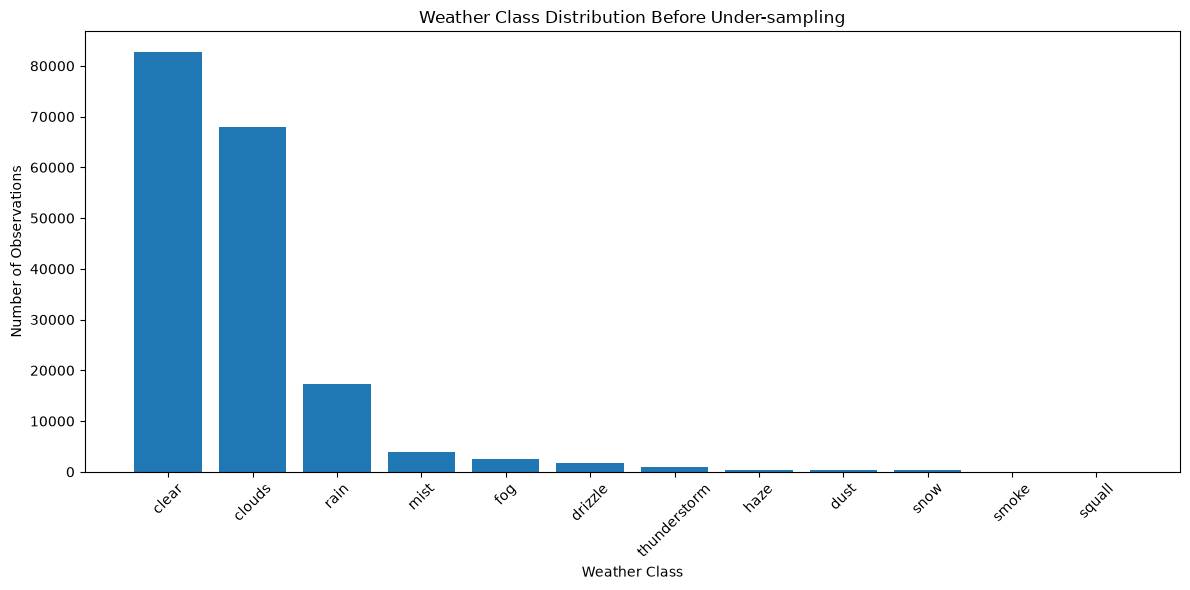

In [61]:
# Vẽ phân bố các lớp Weather trước khi under-sampling
class_counts = weather_outlier_clean['weather_main'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(class_counts.index, class_counts.values)

plt.title('Weather Class Distribution Before Under-sampling')
plt.xlabel('Weather Class')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Phân bố lớp mất cân bằng nghiêm trọng khi Clear và Clouds áp đảo phần còn lại, dễ làm mô hình thiên lệch về phía nhóm đa số nếu dùng weather_main làm biến mục tiêu. Tuy nhiên, các lớp thời tiết cực hiếm (Smoke, Squall) vẫn mang ý nghĩa thực tế nên không thể xóa bỏ. Do đó, phương án tối ưu là áp dụng chiến lược giảm mẫu chọn lọc (conservative under-sampling) chỉ đối với nhóm đa số.

3.1 Xử lý bằng Under-Sampling

In [62]:
# Tạo bản sao từ dataset sau khi xử lý duplicate và outliers
weather_balanced = weather_outlier_clean.copy()

# Kiểm tra biến mục tiêu
class_counts_before = weather_balanced['weather_main'].value_counts()
print(class_counts_before)

# Chọn số lượng của lớp thiểu số lớn nhất trong nhóm đa số cần under-sampling
target_count = class_counts_before['rain']
print("\nTarget count for clear/clouds:", target_count)


weather_main
clear           82670
clouds          68050
rain            17390
mist             3908
fog              2506
drizzle          1724
thunderstorm     1041
haze              435
dust              347
snow              270
smoke              33
squall              1
Name: count, dtype: int64

Target count for clear/clouds: 17390


In [63]:
# Under-sample Clear
clear_sample = weather_balanced[
    weather_balanced['weather_main'] == 'clear'
].sample(
    n=target_count,
    random_state=42
)

# Under-sample Clouds
clouds_sample = weather_balanced[
    weather_balanced['weather_main'] == 'clouds'
].sample(
    n=target_count,
    random_state=42
)

# Keep all other classes
other_classes = weather_balanced[
    ~weather_balanced['weather_main'].isin(['clear', 'clouds'])
]

# Combine all data
weather_balanced = pd.concat(
    [clear_sample, clouds_sample, other_classes],
    ignore_index=True
)

# Shuffle
weather_balanced = weather_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Before:", weather_outlier_clean.shape)
print("After:", weather_balanced.shape)


Before: (178375, 17)
After: (62435, 17)


In [64]:
print("Class distribution after under-sampling:")
print(weather_balanced['weather_main'].value_counts())

print("\nExact duplicates after under-sampling:",
      weather_balanced.duplicated().sum())


Class distribution after under-sampling:
weather_main
clear           17390
rain            17390
clouds          17390
mist             3908
fog              2506
drizzle          1724
thunderstorm     1041
haze              435
dust              347
snow              270
smoke              33
squall              1
Name: count, dtype: int64

Exact duplicates after under-sampling: 0


### Kết luận

Sau khi under-sampling, số lượng của hai lớp đa số `clear` và `clouds` được giảm xuống bằng với lớp `rain` (17.391 quan sát).

Các lớp ít phổ biến hơn được giữ nguyên nhằm tránh làm mất quá nhiều dữ liệu, đặc biệt đối với các lớp rất hiếm như `smoke` và `squall`.

Do đó, `weather_balanced` là tập dữ liệu đã **giảm mức độ mất cân bằng**, chứ không đạt trạng thái cân bằng hoàn toàn giữa tất cả các lớp.


## 4. BONUS – LOG TRANSFORMATION

Log Transformation là một kỹ thuật biến đổi dữ liệu nhằm giảm độ lệch của các biến số có phân phối right-skewed (lệch phải).

Trong dữ liệu, một số biến có nhiều giá trị nhỏ nhưng chỉ có một số ít giá trị rất lớn. Những giá trị lớn này có thể làm phân phối bị lệch mạnh. Log Transformation giúp nén các giá trị lớn, từ đó làm phân phối cân đối hơn.


### 4.1 Energy

Trong tập Energy, biến `generation fossil gas` có phân phối lệch phải và có một số giá trị lớn hơn đáng kể so với phần lớn dữ liệu.

Tuy nhiên, các giá trị lớn này không nhất thiết là dữ liệu lỗi, vì chúng có thể phản ánh mức phát điện thực tế. Vì vậy, thay vì loại bỏ các giá trị này, Log Transformation được sử dụng như một cách biến đổi phân phối.


In [65]:
energy_bonus = energy_outlier_clean.copy()

energy_bonus['generation fossil gas'] = np.log1p(
    energy_bonus['generation fossil gas']
)

In [66]:
# kiểm tra độ lệch (skewness) trước và sau khi log-transform
print("Skewness before:")
print(energy_outlier_clean['generation fossil gas'].skew())

print("\nSkewness after:")
print(energy_bonus['generation fossil gas'].skew())

Skewness before:
1.6154025535461605

Skewness after:
0.18777573758174934


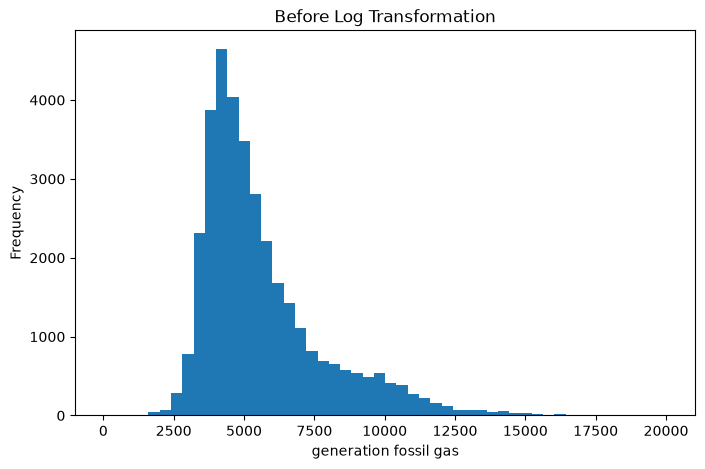

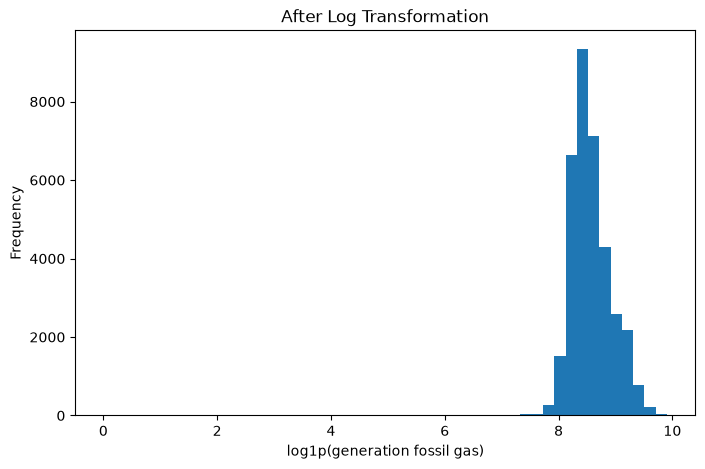

In [67]:
plt.figure(figsize=(8, 5))

plt.hist(
    energy_outlier_clean['generation fossil gas'],
    bins=50
)

plt.title('Before Log Transformation')
plt.xlabel('generation fossil gas')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))

plt.hist(
    energy_bonus['generation fossil gas'],
    bins=50
)

plt.title('After Log Transformation')
plt.xlabel('log1p(generation fossil gas)')
plt.ylabel('Frequency')
plt.show()

### 4.2 Weather

Trong tập Weather, biến `wind_speed` có phân phối lệch phải, với phần lớn giá trị tập trung ở mức thấp và một số giá trị cao hơn đáng kể.

Do đó, Log Transformation được áp dụng để giảm ảnh hưởng của phần đuôi phải của phân phối.


In [68]:
weather_bonus = weather_outlier_clean.copy()

weather_bonus['wind_speed'] = np.log1p(
    weather_bonus['wind_speed']
)

In [69]:
# Kiểm tra độ lệch (skewness) trước và sau khi log-transform
print("Skewness before:")
print(weather_outlier_clean['wind_speed'].skew())

print("\nSkewness after:")
print(weather_bonus['wind_speed'].skew())

Skewness before:
1.8783599377690627

Skewness after:
-0.05326952942475689


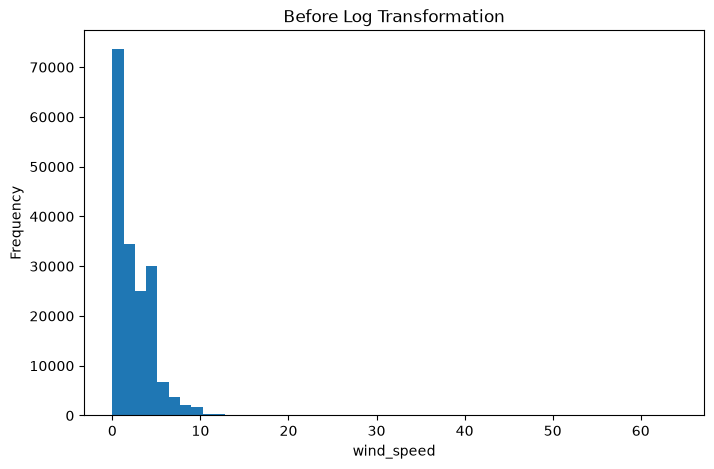

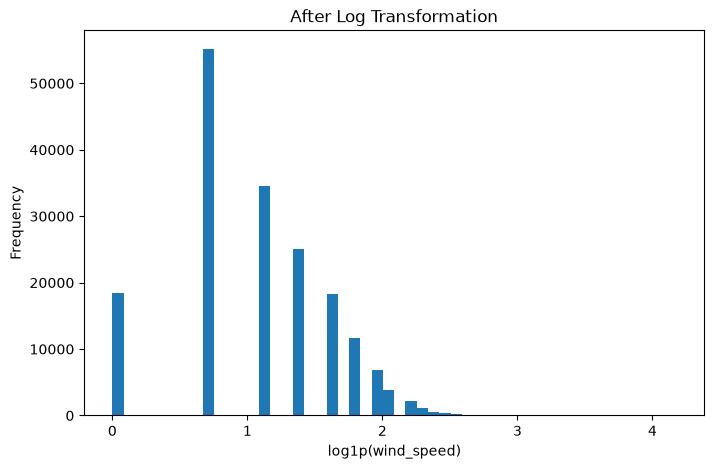

In [70]:
plt.figure(figsize=(8, 5))

plt.hist(
    weather_outlier_clean['wind_speed'],
    bins=50
)

plt.title('Before Log Transformation')
plt.xlabel('wind_speed')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))

plt.hist(
    weather_bonus['wind_speed'],
    bins=50
)

plt.title('After Log Transformation')
plt.xlabel('log1p(wind_speed)')
plt.ylabel('Frequency')
plt.show()

-> Kết luận: Phép biến đổi logarit đã được áp dụng cho các biến số định lượng lệch phải được chọn trong bộ dữ liệu Năng lượng và Thời tiết. Kỹ thuật này được chọn để giảm độ lệch của phân bố trong khi vẫn giữ lại các quan sát ban đầu thay vì loại bỏ các giá trị cực đoan có thể hợp lệ. Hàm log1p() được sử dụng vì các biến được chọn có thể chứa giá trị bằng không. Độ lệch trước và sau khi biến đổi được so sánh để đánh giá hiệu quả của phép biến đổi.

**Lưu ý:** Log Transformation được trình bày như một kỹ thuật biến đổi bổ sung (bonus) và được thực hiện trên các bản sao `energy_bonus` và `weather_bonus`. Các file xuất cuối của pipeline chính vẫn sử dụng dữ liệu sau Missing Values, Removing Duplicates, Drop Constant Features, Outliers và Under-Sampling.


## 5. FINAL DATASETS


### A. Energy dataset sau khi xử lý missing values, constant features và outliers


### B. Weather dataset sau khi xử lý duplicates và outliers


### C. Weather dataset sau khi xử lý duplicates, outliers và imbalance


In [71]:
# Export các dataset cuối
energy_outlier_clean.to_csv(
    "energy_outlier_clean.csv",
    index=False
)

weather_outlier_clean.to_csv(
    "weather_outlier_clean.csv",
    index=False
)

weather_balanced.to_csv(
    "weather_balanced.csv",
    index=False
)

print("Files exported successfully!")


Files exported successfully!


In [72]:
# Kiểm tra các dataset cuối
print("===== FINAL DATASETS =====")
print("Energy:", energy_outlier_clean.shape)
print("Weather:", weather_outlier_clean.shape)
print("Weather balanced:", weather_balanced.shape)

print("\n===== EXACT DUPLICATES =====")
print("Energy:", energy_outlier_clean.duplicated().sum())
print("Weather:", weather_outlier_clean.duplicated().sum())
print("Weather balanced:", weather_balanced.duplicated().sum())

print("\n===== REMAINING CONSTANT FEATURES IN ENERGY =====")
remaining_constant_cols = [
    col for col in energy_outlier_clean.columns
    if energy_outlier_clean[col].nunique(dropna=False) <= 1
]
print(remaining_constant_cols)

print("\n===== EXPORTED FILES =====")
import os
for file in [
    "energy_outlier_clean.csv",
    "weather_outlier_clean.csv",
    "weather_balanced.csv"
]:
    print(file, "->", os.path.exists(file))


===== FINAL DATASETS =====
Energy: (35064, 21)
Weather: (178375, 17)
Weather balanced: (62435, 17)

===== EXACT DUPLICATES =====
Energy: 0
Weather: 0
Weather balanced: 0

===== REMAINING CONSTANT FEATURES IN ENERGY =====
[]

===== EXPORTED FILES =====
energy_outlier_clean.csv -> True
weather_outlier_clean.csv -> True
weather_balanced.csv -> True


In [73]:
# Final missing value check
print("===== FINAL MISSING VALUE CHECK =====")
print("Energy missing:", energy_outlier_clean.isna().sum().sum())
print("Weather missing:", weather_outlier_clean.isna().sum().sum())
print("Weather balanced missing:", weather_balanced.isna().sum().sum())


===== FINAL MISSING VALUE CHECK =====
Energy missing: 0
Weather missing: 0
Weather balanced missing: 0
